In [22]:
import numpy as np
from typing import Tuple,Dict,Optional,Any
from dataclasses import dataclass
from scipy.sparse.linalg import eigsh
import cvxpy as cp

import os
os.environ['PYDEVD_DISABLE_FILE_VALIDATION'] = '1'

import tqdm as tqdm
from matplotlib import pyplot as plt


eucn = np.linalg.norm
sqrt = np.sqrt

# Useful Functions

In [23]:


@dataclass
class FactorModelData:
    """
    Factor model: Sigma = B' F B + D
    where B is (k, p), F is (k, k) diagonal, D is (p, p) diagonal
    
    Attributes
    ----------
    B : np.ndarray, shape (k, p)
        Factor loading matrix (k factors, p assets)
    F : np.ndarray, shape (k,) or (k, k)
        Factor covariance (diagonal elements or full diagonal matrix)
    D : np.ndarray, shape (p,) or (p, p)
        Specific variance (diagonal elements or full diagonal matrix)
    metadata: Optional dictionary with generation parameters

    """
    B: np.ndarray  # (k, p)
    F: np.ndarray  # (k,) or (k, k) diagonal
    D: np.ndarray  # (p,) or (p, p) diagonal
    metadata: Optional[Dict[str, Any]] = None

    
    def __post_init__(self):
        """Validate and standardize dimensions."""
        self.B = np.atleast_2d(self.B)
        k, p = self.B.shape
        
        # Extract diagonals if full matrices provided
        if self.F.ndim == 2:
            if self.F.shape != (k, k):
                raise ValueError(f"F shape {self.F.shape} incompatible with B shape {self.B.shape}")
            self.F = np.diag(self.F)
        else:
            self.F = np.asarray(self.F).ravel()
            if self.F.shape[0] != k:
                raise ValueError(f"F length {self.F.shape[0]} incompatible with k={k}")
        
        if self.D.ndim == 2:
            if self.D.shape != (p, p):
                raise ValueError(f"D shape {self.D.shape} incompatible with B shape {self.B.shape}")
            self.D = np.diag(self.D)
        else:
            self.D = np.asarray(self.D).ravel()
            if self.D.shape[0] != p:
                raise ValueError(f"D length {self.D.shape[0]} incompatible with p={p}")
    
    @property
    def k(self) -> int:
        """Number of factors."""
        return self.B.shape[0]
    
    @property
    def p(self) -> int:
        """Number of assets."""
        return self.B.shape[1]
    
    def compute_covariance(self) -> np.ndarray:
        """
        Compute full covariance matrix Sigma = B' F B + D.
        Warning: Forms full p×p matrix - use only for small p.
        """
        return self.B.T @ (np.diag(self.F) @ self.B) + np.diag(self.D)
    
    def gradient(self, w: np.ndarray) -> np.ndarray:
        """
        Compute gradient g = 2 * Sigma @ w without forming Sigma.
        
        g = 2 * (B' F B + D) w
          = 2 * (B' (F (B w)) + D w)
        """
        w = np.asarray(w).ravel()
        if w.shape[0] != self.p:
            raise ValueError(f"Weight dimension {w.shape[0]} != p={self.p}")
        
        f = self.B @ w              # (k,) factor exposures
        g = 2.0 * (self.B.T @ (self.F * f) + self.D * w)  # (p,) gradient
        return g
    
    def portfolio_variance(self, w: np.ndarray) -> float:
        """
        Compute portfolio variance w' Sigma w without forming Sigma.
        
        var = w' (B' F B + D) w
            = (Bw)' F (Bw) + w' D w
        """
        w = np.asarray(w).ravel()
        if w.shape[0] != self.p:
            raise ValueError(f"Weight dimension {w.shape[0]} != p={self.p}")
        
        f = self.B @ w              # (k,) factor exposures
        factor_var = f @ (self.F * f)
        specific_var = w @ (self.D * w)
        return factor_var + specific_var
    
    def remove_factor(self, factor_idx: int) -> 'FactorModelData':
        """Removes a factor from the model data.  Used to keep consistent model for examples"""
        if factor_idx < 0 or factor_idx >= self.k:
            raise IndexError(f"Factor index {factor_idx} out of bounds for k={self.k}")
        
        B_new = np.delete(self.B, factor_idx, axis=0)
        if self.F.ndim>1:
            F_new = np.delete(np.delete(self.F, factor_idx, axis=0), factor_idx, axis=1)
        else:
            F_new = np.delete(self.F,factor_idx,axis=0)
        
        return FactorModelData(B_new, F_new, self.D, self.metadata)


def ffp_minvar(model: FactorModelData, max_iters: int = 1000, 
               tol: float = 1e-12, verbose: bool = False) -> Dict:
    """
    FFP algorithm for factor model minimum variance.
    
    Solves: min w' (B' F B + D) w  subject to  sum(w) = 1, w >= 0
    where B is (k, p), F is (k, k) diagonal, D is (p, p) diagonal
    
    Parameters
    ----------
    model : FactorModelData
        Factor model with B (k×p), F (k,), D (p,)
    max_iters : int
        Maximum iterations
    tol : float
        Convergence tolerance
    verbose : bool
        Print convergence info
    
    Returns
    -------
    dict with keys:
        w : (p,) optimal weights
        lambda : Lagrange multiplier for sum constraint
        nu : (p,) Lagrange multipliers for non-negativity
        theta : (k,) dual variable in factor space
        iters : number of iterations
        converged : bool
    """
    k, p = model.k, model.p
    B = model.B  # (k, p)
    F = model.F  # (k,)
    if F.ndim>1:
        F = np.diag(F)
    d = model.D  # (p,)
    if d.ndim>1:
        d = np.diag(d)
    
    # Algorithm setup
    e = np.ones(p)
    Finv = 1.0 / F        # (k,) inverse of factor variances
    dinv = 1.0 / d        # (p,) inverse of specific variances
    
    # Initialize theta (dual variable in k-dimensional factor space)
    theta_old = np.zeros(k)
    theta_new = np.ones(k)
    
    for iter_count in range(max_iters):
        # Check convergence
        if np.allclose(theta_new, theta_old, atol=tol):
            if verbose:
                print(f"FFP converged in {iter_count} iterations")
            converged = True
            break
        
        # Update
        theta_old = theta_new.copy()  # CRITICAL: must copy
        
        # Compute gap and active set
        # gap[i] = 1 - (B' theta)[i]  where B' is (p, k)
        gap = e - B.T @ theta_old  # (p,) gap vector
        active_mask = (gap > 0).astype(float)  # (p,) indicator: 1 if active, 0 if inactive
        
        # Weighted inverse diagonal: active assets get 1/d[i], inactive get 0
        D_active_inv = active_mask * dinv  # (p,)
        
        # Solve for new theta:
        # (F^{-1} + B diag(D_active_inv) B') theta = B diag(D_active_inv) 1
        # where B is (k, p) and B' is (p, k)
        A = np.diag(Finv) + B @ (D_active_inv[:, None] * B.T)  # (k, k)
        b = B @ D_active_inv  # (k,) = (k, p) @ (p,)
        theta_new = np.linalg.solve(A, b)
    else:
        if verbose:
            print(f"FFP did not converge in {max_iters} iterations")
        converged = False
        iter_count = max_iters
    
    # Compute final weights
    gap = e - B.T @ theta_new  # (p,)
    w = np.maximum(0, gap * dinv)  # w[i] = max(0, gap[i]/d[i])
    
    # Normalize (should already sum to ~1, but ensure exactness)
    w_sum = w.sum()
    if w_sum > 0:
        w = w / w_sum
    else:
        # Degenerate case - return equal weights
        w = e / p
    
    # Compute dual variables for KKT
    g = model.gradient(w)  # (p,) gradient
    
    # Lambda (dual for sum-to-one constraint)
    active = w > tol
    if np.any(active):
        lambda_hat = np.mean(g[active])
    else:
        lambda_hat = 0.0
    
    # Nu (dual for non-negativity constraints)
    nu = np.maximum(0, lambda_hat - g)  # (p,) nu[i] >= 0, nu[i]*w[i] = 0
    
    return {
        'w': w,
        'lambda': lambda_hat,
        'nu': nu,
        'theta': theta_new,
        'iters': iter_count,
        'converged': converged,
        'active_mask': active
    }


def check_kkt_minvar_factor(model: FactorModelData, w: np.ndarray, 
                     lambda_val: Optional[float] = None, 
                     nu: Optional[np.ndarray] = None,
                     tol: float = 1e-10, 
                     grad_tol: float = 1e-6) -> Dict:
    """
    Check KKT conditions for factor model minimum variance.
    
    KKT conditions for: min w' Sigma w  s.t.  sum(w) = 1, w >= 0
    
    1. Primal feasibility: sum(w) = 1, w >= 0
    2. Dual feasibility: nu >= 0
    3. Stationarity: 2*Sigma*w - lambda*1 - nu = 0
    4. Complementary slackness: nu[i]*w[i] = 0 for all i
    
    Parameters
    ----------
    model : FactorModelData
        Factor model
    w : np.ndarray, shape (p,)
        Weights to check
    lambda_val : float, optional
        Lagrange multiplier for sum constraint (estimated if not provided)
    nu : np.ndarray, optional
        Lagrange multipliers for non-negativity (estimated if not provided)
    tol : float
        Tolerance for detecting zero weights
    grad_tol : float
        Tolerance for KKT conditions
    
    Returns
    -------
    dict with detailed KKT check results
    """
    p = model.p
    w = np.asarray(w).ravel()
    
    if w.shape[0] != p:
        raise ValueError(f"Weight dimension {w.shape[0]} != p={p}")
    
    # Compute gradient: g = 2 * Sigma @ w
    g = model.gradient(w)  # (p,)
    
    # Active/inactive sets
    active = w > tol
    inactive = ~active
    
    # 1. Primal feasibility
    sum_check = np.isclose(w.sum(), 1.0, atol=1e-8)
    non_neg_check = np.all(w >= -tol)
    primal_feasible = sum_check and non_neg_check
    
    if not np.any(active):
        return {
            'primal_feasible': primal_feasible,
            'is_kkt_satisfied': False,
            'reason': 'No active assets',
            'active_count': 0,
            'inactive_count': p
        }
    
    # 2. Estimate lambda if not provided
    if lambda_val is None:
        lambda_val = np.mean(g[active])
    
    # 3. Estimate nu if not provided

    if nu is None:
        nu = np.where(active, 0.0, g - lambda_val)  # Active: 0, Inactive: g - lambda

    # 4. Check stationarity: g - lambda*1 - nu = 0
    # Equivalently: g = lambda + nu
    stationarity_residual = g - lambda_val - nu
    stationarity_check = np.allclose(stationarity_residual, 0, atol=grad_tol)
    
    # 5. Check dual feasibility: nu >= 0
    dual_feasible = np.all(nu >= -grad_tol)
    
    # 6. Check complementary slackness: nu[i]*w[i] = 0
    comp_slack_violations = np.abs(nu * w)
    comp_slack_check = np.all(comp_slack_violations < grad_tol)
    
    # Alternative checks (equivalent formulation)
    # On active set: g[i] = lambda (since nu[i] = 0)
    # On inactive set: g[i] <= lambda (since w[i] = 0)
    active_stationarity = np.allclose(g[active], lambda_val, atol=grad_tol)
    # inactive_dual = np.all(g[inactive] <= lambda_val + grad_tol)
    # NEW (CORRECT):
    inactive_dual = np.all(g[inactive] >= lambda_val - grad_tol) if np.any(inactive) else True  # g should be >= lambda

    # Compute violations
    max_stationarity_viol = np.max(np.abs(stationarity_residual))
    max_dual_viol = np.max(-nu) if not dual_feasible else 0.0
    max_comp_slack_viol = np.max(comp_slack_violations)
    max_active_viol = np.max(np.abs(g[active] - lambda_val))
    # max_inactive_viol = np.max(np.maximum(0, g[inactive] - lambda_val)) if np.any(inactive) else 0.0
    # NEW (CORRECT):
    if np.any(inactive):
        max_inactive_viol = np.max(np.maximum(0, lambda_val - g[inactive]))
    else:
        max_inactive_viol = 0.0
    max_violation = max(max_stationarity_viol, max_dual_viol, max_comp_slack_viol)
    
    is_kkt = (primal_feasible and dual_feasible and 
              stationarity_check and comp_slack_check)
    
    return {
        # Overall
        'is_kkt_satisfied': is_kkt,
        'max_violation': max_violation,
        
        # Primal
        'primal_feasible': primal_feasible,
        'sum_weights': float(w.sum()),
        'min_weight': float(w.min()),
        'max_weight': float(w.max()),
        
        # Dual
        'lambda': float(lambda_val),
        'dual_feasible': dual_feasible,
        'max_dual_violation': float(max_dual_viol),
        
        # Stationarity
        'stationarity_satisfied': stationarity_check,
        'max_stationarity_violation': float(max_stationarity_viol),
        'stationarity_residual': stationarity_residual,
        
        # Complementary slackness
        'complementary_slackness_satisfied': comp_slack_check,
        'max_comp_slack_violation': float(max_comp_slack_viol),
        
        # Alternative formulation
        'active_stationarity': active_stationarity,
        'inactive_dual_feasibility': inactive_dual,
        'max_active_violation': float(max_active_viol),
        'max_inactive_violation': float(max_inactive_viol),
        
        # Counts
        'active_count': int(np.sum(active)),
        'inactive_count': int(np.sum(inactive)),
        
        # Details
        'gradient': g,
        'nu': nu,
        'active_indices': np.where(active)[0],
        'inactive_indices': np.where(inactive)[0]
    }


def diagnose_minvar_solution(model: FactorModelData, w: np.ndarray,
                             lambda_val: Optional[float] = None,
                             nu: Optional[np.ndarray] = None,
                             tol: float = 1e-10, 
                             grad_tol: float = 1e-6) -> Dict:
    """
    Print detailed diagnostics for a minimum variance solution.
    """
    kkt = check_kkt_minvar_factor(model, w, lambda_val, nu, tol, grad_tol)
    
    # Portfolio variance
    portfolio_var = model.portfolio_variance(w)
    
    print("=" * 70)
    print("MINIMUM VARIANCE SOLUTION DIAGNOSTICS")
    print("=" * 70)
    print(f"Status: {'✓ KKT SATISFIED' if kkt['is_kkt_satisfied'] else '✗ KKT VIOLATED'}")
    print()
    
    print(f"PROBLEM DIMENSIONS:")
    print(f"  Factors (k): {model.k}")
    print(f"  Assets (p): {model.p}")
    print()
    
    print("PRIMAL FEASIBILITY:")
    print(f"  Sum of weights: {kkt['sum_weights']:.10f} (should be 1.0)")
    print(f"  Min weight: {kkt['min_weight']:.10e} (should be >= 0)")
    print(f"  Max weight: {kkt['max_weight']:.6f}")
    print(f"  Feasible: {kkt['primal_feasible']}")
    print()
    
    print("ACTIVE SET:")
    print(f"  Active assets: {kkt['active_count']}/{model.p}")
    print(f"  Inactive assets: {kkt['inactive_count']}/{model.p}")
    if kkt['active_count'] > 0 and kkt['active_count'] <= 10:
        print(f"  Active indices: {kkt['active_indices'].tolist()}")
        print(f"  Active weights: {w[kkt['active_indices']].tolist()}")
    print()
    
    g = kkt['gradient']
    print("GRADIENT (g = 2*Sigma*w):")
    print(f"  Min gradient: {g.min():.10f}")
    print(f"  Max gradient: {g.max():.10f}")
    print(f"  Range: {g.max() - g.min():.10e}")
    if kkt['lambda'] is not None:
        print(f"  Lambda (avg on active): {kkt['lambda']:.10f}")
    print()
    
    print("KKT CONDITIONS:")
    print(f"  Stationarity (g = lambda + nu): {kkt['stationarity_satisfied']}")
    print(f"    Max violation: {kkt['max_stationarity_violation']:.10e}")
    
    print(f"  Dual feasibility (nu >= 0): {kkt['dual_feasible']}")
    print(f"    Max violation: {kkt['max_dual_violation']:.10e}")
    
    print(f"  Complementary slackness (nu*w = 0): {kkt['complementary_slackness_satisfied']}")
    print(f"    Max violation: {kkt['max_comp_slack_violation']:.10e}")
    
    print(f"\n  Alternative formulation:")
    print(f"    Active stationarity (g[active] = lambda): {kkt['active_stationarity']}")
    print(f"      Max violation: {kkt['max_active_violation']:.10e}")
    print(f"    Inactive dual (g[inactive] <= lambda): {kkt['inactive_dual_feasibility']}")
    print(f"      Max violation: {kkt['max_inactive_violation']:.10e}")
    
    print(f"\n  Overall max violation: {kkt['max_violation']:.10e}")
    print()
    
    print("OBJECTIVE:")
    print(f"  Portfolio variance: {portfolio_var:.10e}")
    print(f"  Portfolio volatility: {np.sqrt(portfolio_var):.10f}")
    print()
    
    # Warnings
    warnings = []
    
    if kkt['max_violation'] > grad_tol * 10:
        warnings.append(f"Large KKT violation ({kkt['max_violation']:.2e}) - solution may be suboptimal")
    
    if np.any((w > tol) & (w < tol * 10)):
        warnings.append(f"Very small positive weights detected - may be numerical noise")
    
    if kkt['active_count'] > 0:
        active_grad_std = np.std(g[kkt['active_indices']])
        if active_grad_std > grad_tol * 10:
            warnings.append(f"High gradient variance on active set ({active_grad_std:.2e})")
    
    if len(warnings) > 0:
        print("WARNINGS:")
        for i, msg in enumerate(warnings, 1):
            print(f"  {i}. {msg}")
        print()
    
    return kkt


def solve_minvar_cvxpy(model: FactorModelData, solver=None, verbose: bool = False) -> Dict:
    """
    Solve minimum variance using CVXPY.
    
    Parameters
    ----------
    model : FactorModelData
        Factor model
    solver : cvxpy solver, optional
        CVXPY solver to use
    verbose : bool
        Print solver output
    
    Returns
    -------
    dict with 'w', 'status', 'optimal_value', 'solver'
    """
    
    p = model.p
    w = cp.Variable(p)
    
    # Objective: w' Sigma w = w' (B' F B + D) w
    # = (B w)' F (B w) + w' D w
    # where B is (k, p)
    factor_exp = model.B @ w  # (k,) factor exposures
    
    factor_risk = cp.quad_form(factor_exp, np.diag(model.F))
    specific_risk = cp.sum(cp.multiply(model.D, cp.square(w)))
    
    objective = cp.Minimize(factor_risk + specific_risk)
    
    constraints = [
        cp.sum(w) == 1,
        w >= 0
    ]
    
    if solver is None:
        solver = cp.CLARABEL
    
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=solver, verbose=verbose)
    
    return {
        'w': w.value,
        'status': prob.status,
        'optimal_value': prob.value,
        'solver': str(solver)
    }


def compare_solutions(model: FactorModelData, 
                     cvxpy_w: np.ndarray, 
                     ffp_result: Dict,
                     tol: float = 1e-10, 
                     grad_tol: float = 1e-6):
    """Compare CVXPY and FFP solutions."""
    
    print("=" * 70)
    print("SOLUTION COMPARISON")
    print("=" * 70)
    
    # Check CVXPY solution
    print("\nCVXPY SOLUTION:")
    cvxpy_kkt = check_kkt_minvar_factor(model, cvxpy_w, tol=tol, grad_tol=grad_tol)
    print(f"  KKT satisfied: {cvxpy_kkt['is_kkt_satisfied']}")
    print(f"  Max violation: {cvxpy_kkt['max_violation']:.2e}")
    print(f"  Active assets: {cvxpy_kkt['active_count']}")
    print(f"  Lambda: {cvxpy_kkt['lambda']:.10f}")
    
    # Check FFP solution
    print("\nFFP SOLUTION:")
    ffp_w = ffp_result['w']
    ffp_kkt = check_kkt_minvar_factor(model, ffp_w,
                               lambda_val=ffp_result['lambda'],
                               nu=ffp_result['nu'],
                               tol=tol, grad_tol=grad_tol)
    print(f"  KKT satisfied: {ffp_kkt['is_kkt_satisfied']}")
    print(f"  Max violation: {ffp_kkt['max_violation']:.2e}")
    print(f"  Active assets: {ffp_kkt['active_count']}")
    print(f"  Lambda: {ffp_kkt['lambda']:.10f}")
    print(f"  Converged: {ffp_result['converged']} ({ffp_result['iters']} iters)")
    
    # Compare weights
    print("\nWEIGHT COMPARISON:")
    w_diff = np.abs(cvxpy_w - ffp_w)
    print(f"  Max weight difference: {np.max(w_diff):.2e}")
    print(f"  Mean weight difference: {np.mean(w_diff):.2e}")
    print(f"  RMS weight difference: {np.sqrt(np.mean(w_diff**2)):.2e}")
    
    # Compare objectives
    obj_cvx = model.portfolio_variance(cvxpy_w)
    obj_ffp = model.portfolio_variance(ffp_w)
    
    print(f"\nOBJECTIVE VALUES:")
    print(f"  CVXPY: {obj_cvx:.10e}")
    print(f"  FFP:   {obj_ffp:.10e}")
    print(f"  Diff:  {abs(obj_cvx - obj_ffp):.2e}")
    print(f"  Rel diff: {abs(obj_cvx - obj_ffp) / obj_cvx * 100:.4f}%")
    
    # Show weights that differ significantly
    significant_diff = w_diff > grad_tol
    if np.any(significant_diff):
        print(f"\nASSETS WITH SIGNIFICANT WEIGHT DIFFERENCES (>{grad_tol}):")
        diff_indices = np.where(significant_diff)[0]
        n_show = min(10, len(diff_indices))
        for i in diff_indices[:n_show]:
            print(f"  Asset {i}: CVXPY={cvxpy_w[i]:.6e}, FFP={ffp_w[i]:.6e}, diff={w_diff[i]:.6e}")
        if len(diff_indices) > n_show:
            print(f"  ... and {len(diff_indices) - n_show} more")
    
    return cvxpy_kkt, ffp_kkt


# Example usage
if __name__ == "__main__":
    # Create test factor model
    np.random.seed(42)
    k, p = 5, 50  # 5 factors, 50 assets
    
    B = np.random.randn(k, p) * 0.3  # (k, p) factor loadings
    F = np.abs(np.random.randn(k)) * 0.1 + 0.01  # (k,) factor variances
    D = np.abs(np.random.randn(p)) * 0.05 + 0.01  # (p,) specific variances
    
    model = FactorModelData(B=B, F=F, D=D)
    
    print(f"Factor model: k={model.k} factors, p={model.p} assets")
    print(f"B shape: {model.B.shape}")
    print(f"F shape: {model.F.shape}")
    print(f"D shape: {model.D.shape}")
    print()
    
    # Solve with FFP
    print("Solving with FFP...")
    ffp_result = ffp_minvar(model, verbose=True)
    print()
    
    # Diagnose FFP solution
    diagnose_minvar_solution(model, ffp_result['w'],
                            lambda_val=ffp_result['lambda'],
                            nu=ffp_result['nu'])
    
    # Optionally compare with CVXPY
    try:
        import cvxpy as cp
        print("\nSolving with CVXPY...")
        cvxpy_result = solve_minvar_cvxpy(model, verbose=False)
        print()
        
        compare_solutions(model, cvxpy_result['w'], ffp_result)
    except ImportError:
        print("CVXPY not available - skipping comparison")

Factor model: k=5 factors, p=50 assets
B shape: (5, 50)
F shape: (5,)
D shape: (50,)

Solving with FFP...
FFP converged in 3 iterations

MINIMUM VARIANCE SOLUTION DIAGNOSTICS
Status: ✓ KKT SATISFIED

PROBLEM DIMENSIONS:
  Factors (k): 5
  Assets (p): 50

PRIMAL FEASIBILITY:
  Sum of weights: 1.0000000000 (should be 1.0)
  Min weight: 3.1850275438e-03 (should be >= 0)
  Max weight: 0.072499
  Feasible: True

ACTIVE SET:
  Active assets: 50/50
  Inactive assets: 0/50

GRADIENT (g = 2*Sigma*w):
  Min gradient: 0.0015563022
  Max gradient: 0.0015563022
  Range: 2.4936649967e-17
  Lambda (avg on active): 0.0015563022

KKT CONDITIONS:
  Stationarity (g = lambda + nu): True
    Max violation: 2.4286128664e-17
  Dual feasibility (nu >= 0): True
    Max violation: 0.0000000000e+00
  Complementary slackness (nu*w = 0): True
    Max violation: 5.1878709196e-19

  Alternative formulation:
    Active stationarity (g[active] = lambda): True
      Max violation: 1.2793585635e-17
    Inactive dual (g[

In [24]:
###### Portfolio related functions


"""
FFP minvar portfolio
Computes x that minimizes x'Qx for a matrix Q=BVB'+D such that
x'e = 1 (where e is the vector of all 1's) and x>0
Note that at each iteration, a memory chunk of size K is wasted
"""
def ffp(model:FactorModelData,maxIters=1000):

    B = model.B.T
    fvar = np.diag(model.F)
    svar = np.diag(model.D)


    # S = B @ (np.diag(fvar) @ B.T) + np.diag(svar)
    S = (B[:, None] * fvar @ B[:, None].T) + np.diag(svar) if B.ndim == 1 else (B * fvar) @ B.T + np.diag(svar)
    p = len(svar)
    e_vec = np.ones(p)
    K = len(fvar)
    Vinv = np.diag(1.0/fvar)
    th_old = np.zeros(K)
    th_new = np.ones(K)
    iters = 0
    inv_svar = 1.0 / svar

    while iters < maxIters:
        # Comparison check: if the change is negligible, exit
        if np.allclose(th_new, th_old, atol=1e-12):
            break
            
        iters += 1
        
        # KEY FIX: .copy() ensures th_old stores the PREVIOUS values
        th_old = th_new.copy() 
        
        # B @ th_old (Matrix-Vector product) handles K=1 or K>1 correctly
        gap = e_vec - B @ th_old
        domg = (gap > 0).astype(float) * inv_svar
        
        # Update th_new (allocates new memory, th_old stays the same)
        A = Vinv + (B.T * domg) @ B
        th_new = np.linalg.solve(A, B.T @ domg)
    w = np.maximum(0, e_vec - B @ th_new) / svar
    x = w/sum(w)
    xn0 = 1*(x!=0)
    L1_1 = 2*x.T @ S #derivative of Objective term of Lagrangian
    y_0 = -np.max( L1_1 @ np.diag(xn0) )  #find dual variable/Lagrange Multiplier for sum to 1 constraint
    y = -(y_0 * e_vec.T + L1_1)
    return (x,y,y_0,iters)




def check_kkt_minvar_old(Sigma, w, tol=1e-8):
    p = len(w)
    g = 2 * Sigma @ w

    # indices
    active = w > tol
    inactive = ~active

    # all active gradients should be (numerically) equal
    lambda_hat = np.mean(g[active])

    kkt1 = np.allclose(g[active], lambda_hat, atol=1e-6)

    # inactive gradients must be >= lambda_hat
    kkt2 = np.all(g[inactive] >= lambda_hat - 1e-8)

    return {
        "kkt_stationarity_active": kkt1,
        "kkt_dual_feasibility_inactive": kkt2,
        "lambda_hat": lambda_hat,
        "violations_active": g[active] - lambda_hat,
        "violations_inactive": g[inactive] - lambda_hat,
        "all_feasible": np.isclose(w.sum(), 1) and np.all(w >= -tol),
        "is_kkt_satisfied": kkt1 and kkt2
    }
def check_kkt_minvar_factor_old(B, F, d, w, tol=1e-10, grad_tol=1e-6):
    """
    Validate LO minvar optimality under factor structure:
        Sigma = B F B^T + diag(d)
    without forming Sigma explicitly.
    """
    k = F.shape[0]
    F = F.reshape(-1,1)
    w = np.asarray(w).reshape(-1,1)
    d = np.asarray(d).reshape(-1,1)
    B = B.reshape(-1,k)
    # 1. Primal feasibility
    sum_to_one = np.isclose(w.sum(), 1.0, atol=1e-8)
    non_negative = np.all(w >= -tol)
    feasible = sum_to_one and non_negative

    # 2. Gradient g = 2 (B F B^T w + D w)
    f = B.T @ w                 # k-vector
    u = B @ (F @ f)             # factor risk piece, p-vector
    v = d * w                   # specific risk piece, p-vector
    g = 2.0 * (u + v)           # gradient

    # 3. Active / inactive sets
    active = w > tol
    inactive = ~active

    if not np.any(active):
        # Degenerate; no positive weights -> not a valid min-var solution
        return {
            "feasible": feasible,
            "has_active_assets": False,
            "is_kkt_satisfied": False,
            "reason": "No active (w_i>0) assets."
        }

    # 4. Lambda: common gradient level on the support
    lambda_hat = np.mean(g[active])

    # Stationarity on the active set: g_i == lambda_hat
    stationarity_active = np.allclose(g[active], lambda_hat, atol=grad_tol)

    # Dual feasibility on inactive: g_i >= lambda_hat
    dual_inactive = np.all(g[inactive] >= lambda_hat - grad_tol)

    return {
        "feasible": feasible,
        "lambda_hat": lambda_hat,
        "stationarity_active": stationarity_active,
        "dual_feasibility_inactive": dual_inactive,
        "is_kkt_satisfied": feasible and stationarity_active and dual_inactive,
        "violations_active": g[active] - lambda_hat,
        "violations_inactive": g[inactive] - lambda_hat,
    }


#### CVXPy for minimum variance portfolio (Long Only)

In [25]:

def risk_objective(x, B, F_sqrt, D_sqrt):
    # Using cp.norm provides the same minimization result 
    # and is often more robust in the CPP backend
    term1 = cp.norm(F_sqrt @ (B @ x), 2)
    term2 = cp.norm(D_sqrt @ x, 2)
    return cp.square(term1) + cp.square(term2)


def LO_minvar(model:FactorModelData):
    F_sqrt = np.diag(np.sqrt(model.F))
    D_sqrt = np.diag(np.sqrt(model.D))
    B = model.B
    p = len(D_sqrt)

    x_minvar = cp.Variable(p)

    constraints_minvar = [
        x_minvar>=0,
        cp.sum(x_minvar) == 1.0,
    ]

    prob_minvar = cp.Problem(cp.Minimize(risk_objective(x_minvar,B,F_sqrt,D_sqrt)), constraints_minvar)
    prob_minvar.solve(solver=cp.CLARABEL)
    return {
        "status": prob_minvar.status,
        "optimal_value": prob_minvar.value,
        "weights": x_minvar.value,
        "dual_variables": constraints_minvar[0].dual_value
    }

# Covariance Estimation Functions

In [26]:

def sample_cov(X: np.ndarray) -> Tuple[np.ndarray, int]:
    """
    X: (p, n) mean-centered returns matrix (rows=assets, columns=time)
    Returns: S = (1/n) X X^T (not n-1), n
    """
    p, n = X.shape
    if n <= 1:
        raise ValueError("需要至少 2 个样本期。")
    S = (X @ X.T) / n
    S = (S + S.T) / 2.0
    return S, n

def top_k_eigenpairs(S: np.ndarray, k: int) -> Tuple[np.ndarray, np.ndarray]:
    """Eigendecomposition of symmetric matrix, return first k (sorted by eigenvalues descending)"""
    vals, vecs = np.linalg.eigh(S)     # ascending order
    idx = np.argsort(vals)[::-1]       # convert to descending order
    vals = vals[idx]
    vecs = vecs[:, idx]
    k = min(k, vecs.shape[1])
    return vecs[:, :k], vals[:k]


def pca_factor_cov(S: np.ndarray, k: int, eps: float = 1e-12) -> np.ndarray:
    """
    PCA factor covariance (paper-aligned baseline for JSE comparisons):

    Use the *sample* top-k eigenvectors/eigenvalues, but keep the same Eq.(37)-style
    low-rank + isotropic residual structure used in `js_eigvec_factor_cov`:

        Σ = U_k diag(max(λ_j - ℓ^2, 0)) U_k^T + (n/p) ℓ^2 I,

    where ℓ^2 is the average of the remaining nonzero eigenvalues of S, and n is
    inferred as rank(S) (in the HL setting with p>n, rank(S)≈n).

    This keeps the comparison focused on eigenvector shrinkage (PCA vs JSE),
    rather than mixing in a different residual model (e.g., diagonal Ψ).
    """
    p = S.shape[0]
    k_eff = max(0, min(k, p - 1))

    # Infer effective n from rank(S). In your setting p >> nobs, rank(S) ≈ nobs.
    # Use a tolerance scaled by matrix magnitude for numerical robustness.
    scale = float(np.linalg.norm(S, ord=2)) if p > 0 else 0.0
    tol = max(eps, 1e-12 * scale)
    n_eff = int(np.linalg.matrix_rank(S, tol=tol))
    n_eff = max(1, min(n_eff, p))

    trS = float(np.trace(S))

    if k_eff == 0:
        # No factors: isotropic covariance consistent with Eq.(37)-style construction.
        # With ℓ^2 = tr(S)/n_eff => (n_eff/p)ℓ^2 = tr(S)/p
        delta2 = max(trS / float(p), eps)
        Sigma = delta2 * np.eye(p)
        Sigma = (Sigma + Sigma.T) / 2.0
        return Sigma

    # Top-k eigenpairs (helper returns (vecs, vals) in descending order)
    U, lam = top_k_eigenpairs(S, k_eff)  # U: (p,k), lam: (k,)

    # Bulk level: ℓ^2 = average of remaining nonzero eigenvalues
    denom = n_eff - k_eff
    if denom <= 0:
        ell2 = 0.0
    else:
        ell2 = (trS - float(np.sum(lam))) / float(denom)
        ell2 = max(ell2, 0.0)

    # Spike strengths are (λ_j - ℓ^2), truncated at 0
    spike = np.maximum(lam - ell2, 0.0)  # (k,)

    Sig_k = U @ (spike[:, None] * U.T)

    # Isotropic residual term: (n/p) ℓ^2 I
    delta2 = (float(n_eff) / float(p)) * ell2
    delta2 = max(delta2, 0.0)

    Sigma = Sig_k + delta2 * np.eye(p)
    Sigma = (Sigma + Sigma.T) / 2.0

    # Factor model parameters
    B = U.T  # k × p
    # CRITICAL: ensure F is always 2D, even when k=1
    F = np.atleast_2d(np.diag(spike))  # k × k (guaranteed 2D)
    D = np.full(p, delta2)  # p (1D array of diagonal values)
    
    model_container = FactorModelData(B, F, D)
    # model_container = FactorModelData(U.T, spike, np.full(p, delta2))

    return Sigma,model_container


def params_sample_covar(Y,k=1,debug=False):

    p,n = Y.shape

    #Dual Sample Covariance Eigenvales and Vectors
    L = Y.T @ Y/p
    vals, vecs = eigsh (np.array(L), k, which='LA')

    vals = vals[::-1] 
    vecs = np.fliplr(vecs)
    #Convert PC's from Dual Covariance
    H = Y @ vecs / np.sqrt(p * vals)
    sH = H
    eigs = vals * p / n

    # Select top k eigenpars
    # if sum(H[:,0]<0):
    #     H = -H
    h = H[:,:k]

    #flip eigenvectors with negative sums
    col_sums = np.sum(h, axis=0)
    flip_mask = col_sums < 0
    h[:, flip_mask] *= -1

    eigs_selected_raw = eigs[:k]
    
    factor_explained_variances = h**2 @ eigs_selected_raw

    #total variance is just the inner product of all p observations with themselves over n
    total_var = np.sum(Y**2, axis=1) / n
    D = np.maximum(total_var - factor_explained_variances, 1e-10)

    #normalize first factor to be mean-1
    beta_mean = np.mean(h[:, 0])
    h[:, 0] = h[:, 0] / beta_mean
    F = eigs_selected_raw.copy()
    F[0] = F[0] * (beta_mean**2)

    # Pre-calculate the systematic covariance matrix from PCA before adjustments
    # so we can "capture" that same variance in our new basis
    # Sigma_sys_pca = (H[:, :k] * eigs[:k]) @ H[:, :k].T. #compute full S- not needed; commented out
    # Factors 2 to K: Standard PCA "Directions"
    # re-orthogonalize higher factors
    for i in range(1, k):
        # Force Mean-0 (Market Neutrality)
        h[:, i] -= np.mean(h[:, i])
        # Project h[i] onto ALL previous factors and subtract (Gram-Schmidt)
        for j in range(i):
            dot_product = np.dot(h[:, i], h[:, j]) / np.dot(h[:, j], h[:, j])
            h[:, i] -= dot_product * h[:, j]
        

        
        # 3. Re-scale to Unit Norm (Consistency in Style Factors)
        norm_i = np.linalg.norm(h[:, i])
        if norm_i > 1e-10:
            h[:, i] /= norm_i

        # 4. Update the eigenvalue efficiently: F[i] = || (H * sqrt(eigs)).T @ h[i] ||^2
        # This avoids building the p x p Sigma_sys_pca matrix entirely
        proj = (H[:, :k] * np.sqrt(eigs_selected_raw[:k])).T @ h[:, i]
        F[i] = np.sum(proj**2)

    
    B = h
    
    Sigma_hat_flat =  (B * F) @ B.T 
    # Add idiosyncratic variance to the diagonal
    np.fill_diagonal(Sigma_hat_flat, Sigma_hat_flat.diagonal() + D)
    Sigma_hat = (Sigma_hat_flat + Sigma_hat_flat.T)/2
    B = B.T # need to reshape to be kxp
    F = np.diag(F) # need to be a diagonal matrix
    D = np.diag(D) # stored as a matrix
    model_container = FactorModelData(B,F,D)
    if(debug):
        # 1. Total Systematic Variance from Original PCA
        pca_sys_var = np.sum(eigs_selected_raw)

        # 2. Total Systematic Variance after Rescaling/Adjusting
        # Since B is (k, p), we check the variance contributed by each factor
        adj_sys_var = np.sum([
            np.dot(model_container.B[i, :], model_container.B[i, :]) * model_container.F[i] 
            for i in range(k)
        ])

        print(f"Original PCA Systematic Variance: {pca_sys_var:.6f}")
        print(f"Adjusted Model Systematic Variance: {adj_sys_var:.6f}")
        print(f"Difference: {pca_sys_var - adj_sys_var:.2e}")

    return Sigma_hat,model_container



def js_eigvec_factor_cov(S: np.ndarray, k: int, n: int, eps: float = 1e-12) -> np.ndarray:
    """
    JS-eigvec factor covariance (aligned to Goldberg–Kercheval JSE paper):
      1) Top k eigenpairs of S: (U_k, Λ_k)
      2) Apply JSE shrinkage to each column of U_k:
         h^JSE = m(h)·1 + c^JSE (h - m(h)·1),
         c^JSE = 1 - ϖ^2 / s^2(h),
         s^2(h) = (λ_j/p) * Σ (h_i - m(h))^2,
         ϖ^2 = ℓ^2 / p,  where ℓ^2 is the average of the remaining nonzero eigenvalues of S
      3) Covariance estimator consistent with Eq. (37)-style construction:
         Σ = Q diag(max(λ_j - ℓ^2, 0)) Q^T + (n/p) ℓ^2 I
         where Q is orthonormalized from the JSE-shrunk vectors.
    """
    p = S.shape[0]
    k_eff = max(0, min(k, p - 1))

    # IMPORTANT: You demean returns over time, so rank(S) is typically nobs-1.
    # To keep PCA vs JSE comparisons paper-aligned (same Eq.(37) structure),
    # use the same "effective n" (= number of nonzero eigenvalues) wherever n enters Eq.(31)/(37).
    scale = float(np.linalg.norm(S, ord=2)) if p > 0 else 0.0
    tol = max(eps, 1e-12 * scale)
    n_eff = int(np.linalg.matrix_rank(S, tol=tol))
    n_eff = max(1, min(n_eff, p, int(n)))

    trS = float(np.trace(S))
    one = np.ones((p, 1))

    if k_eff == 0:
        # No factors: isotropic covariance consistent with Eq.(37)-style construction.
        # With ℓ^2 = tr(S)/n_eff => (n_eff/p)ℓ^2 = tr(S)/p
        delta2 = max(trS / float(p), eps)
        Sigma = delta2 * np.eye(p)
        Sigma = (Sigma + Sigma.T) / 2.0
        return Sigma

    # Top-k eigenpairs (note: your helper returns (vecs, vals))
    U, lam = top_k_eigenpairs(S, k_eff)  # U: (p,k), lam: (k,)

    # ---- Paper-aligned bulk level: ℓ^2 = average of remaining nonzero eigenvalues ----
    denom = n_eff - k_eff
    if denom <= 0:
        ell2 = 0.0
    else:
        ell2 = (trS - float(np.sum(lam))) / float(denom)
        ell2 = max(ell2, 0.0)

    varpi2 = ell2 / float(p)  # ϖ^2 = ℓ^2 / p

    # ---- Column-wise JSE shrinkage ----
    U_js = U.copy()
    for j in range(k_eff):
        h = U[:, j:j+1]
        if float(h.mean()) < 0:
            h = -h

        m = float(h.mean())
        h_c = h - m * one

        lamj = float(lam[j])  # eigenvalue λ_j (paper denotes leading eigenvalue as λ^2)
        s2 = lamj * float(np.sum(h_c ** 2)) / float(p)  # s^2(h)

        c = 1.0 - (varpi2 / (s2 + 1e-18))  # c^JSE
        c = max(0.0, c)  # positive-part truncation to avoid sign-flip amplification
        U_js[:, j:j+1] = m * one + c * h_c

    # Orthonormalize + align signs with original U
    Q, _ = np.linalg.qr(U_js)
    for j in range(k_eff):
        if float(np.dot(Q[:, j], U[:, j])) < 0:
            Q[:, j] *= -1.0

    # ---- Paper-aligned covariance construction (Eq. (37) style) ----
    spike = np.maximum(lam - ell2, 0.0)  # (k,)
    Sig_k = Q @ (spike[:, None] * Q.T)   # Q diag(spike) Q^T

    # Idiosyncratic (isotropic) variance term: (n/p) ℓ^2 I  with n = n_eff
    delta2 = (float(n_eff) / float(p)) * ell2
    Sigma = Sig_k + delta2 * np.eye(p)

    Sigma = (Sigma + Sigma.T) / 2.0

    # Factor model parameters
    B = Q.T  # k × p
    # CRITICAL: ensure F is always 2D, even when k=1
    F = np.atleast_2d(np.diag(spike))  # k × k (guaranteed 2D)
    D = np.full(p, delta2)  # p (1D array of diagonal values)
    
    model_container = FactorModelData(B, F, D)

    return Sigma,model_container



def gmv_unconstrained(Sigma: np.ndarray) -> np.ndarray:
    """
    GMV closed form: w ~ Σ^{-1} 1, normalized to 1' w = 1
    """
    p = Sigma.shape[0]
    ones = np.ones(p)
    try:
        inv_S = np.linalg.solve(Sigma, np.eye(p))
    except np.linalg.LinAlgError:
        inv_S = np.linalg.pinv(Sigma)
    w = inv_S @ ones
    denom = ones @ w
    if abs(denom) < 1e-12:
        raise ValueError("GMV closed form: denominator nearly zero.")
    return w / denom


def herfindahl(weights) -> float:
    """
    herfindahl index returns the sum of the (weights/GE)^2
    GE is sum of absolute values of weights
    measure of concentration
    :param weights: portfolio weights
    :return herfindahl: index
    """
    GE = sum(abs(weights))
    return sum((weights/GE)**2)

def calculate_np(weights,truncation_level=1E-6) -> int:
    """
    number of active weights in LO portfolio
    
    :param weights: portfolio weights
    :return: integer number of positive weights (LO means only +ve or 0)
    :rtype: int
    """
    return int(sum(weights>truncation_level))

# True Model Generation

In [27]:
p = 500
n_days = 63
k = 2

sigma_1 = 0.16
sigma_2 = 0.05
Delta = np.diag(np.random.uniform(0.2,0.7,p))

beta_1 = np.random.normal(1,0.75,(p,1))
beta_2 = np.random.normal(0,0.75,(p,1))

t_gen = lambda n,df,m,s=1: m+s*np.random.standard_t(df = df,size=n)


B2 = np.hstack((beta_1,beta_2))
F2 = np.diag(np.array([sigma_1,sigma_2])**2)
B = beta_1
F = np.array(sigma_1**2, ndmin=2)

## 1-factor truth check

In [28]:
Sigma_True_1fact =  B @ (F @ B.T) + Delta
cond_output = np.linalg.cond(Sigma_True_1fact)
v,d = np.linalg.eigh(Sigma_True_1fact)
print(f"Python Function Output: {cond_output}, Eigenvalue Check: {np.max(v)/np.min(v)}")


Python Function Output: 110.61568025991379, Eigenvalue Check: 110.61568025991382


## 2-factor truth check

In [29]:
Sigma_True_2fact =  B2 @ (F2 @ B2.T) + Delta
cond_output = np.linalg.cond(Sigma_True_2fact)
v,d = np.linalg.eigh(Sigma_True_2fact)
print(f"Python Function Output: {cond_output}, Eigenvalue Check: {np.max(v)/np.min(v)}")


Python Function Output: 110.607478200046, Eigenvalue Check: 110.60747820004605


## Returns Parameters

In [30]:
true_model_2fact = FactorModelData(B2.T,F2,Delta)
true_model_1fact = true_model_2fact.remove_factor(1)


n_runs = 500
truncation_level = 1e-6
f1_df = 4
f1_returns_mean = 0
f1_returns_vol = sqrt((true_model_2fact.F)[0]) # 0.18
f2_df = 5
f2_returns_mean = 0
f2_returns_vol = sqrt((true_model_2fact.F)[1]) #1 #0.05

specific_df = 3
specific_returns_mean = 0
specific_returns_vol = 0.4

In [31]:
def generate_returns_from_model(data_model:FactorModelData, n_days:int, factor_returns:np.ndarray, specific_return:np.ndarray)->np.ndarray:
    """
    Generate asset returns from a given factor data model over n_days.
    :param data_model: FactorDataModel instance containing B, F, D
    :param n_days: Number of days to simulate returns for
    :param factor_returns: Mean returns for each factor for each day; should be (n_days,k)
    :param specific_mean: Mean return for idiosyncratic component for each asset and each day.  should be (p,n_days)
    :return: Simulated asset returns matrix of shape (p, n_days)
    """
    try:
        B = data_model.B #should be (k,p)
        F = data_model.F #should be (k,k)
        D = data_model.D #should be (p,p) diagonal 
    except AttributeError:
        raise ValueError("data_model must be an instance of FactorDataModel")
    k,p = B.shape
    
    # Validate and reshape factor_returns if needed
    if factor_returns.shape == (n_days, k):
        pass  # correct shape
    elif factor_returns.shape == (k, n_days):
        factor_returns = factor_returns.T  # transpose to (n_days, k)
    else:
        raise ValueError(f"factor_returns must be of shape ({n_days},{k}) or ({k},{n_days}), got {factor_returns.shape}")
    
    asset_returns =  factor_returns @ B + specific_return  # (n_days,k) @ (k,p) = (n_days,p)
    return asset_returns.T

## Gaussian Returns Check

In [32]:

# gaussian returns data
f1_gaussian_returns = np.random.normal(f1_returns_mean,f1_returns_vol,size=(n_days,1))
f2_gaussian_returns = np.random.normal(f2_returns_mean,f2_returns_vol,size=(n_days,1))
specific_gaussian_returns = np.random.normal(specific_returns_mean,specific_returns_vol,size=(n_days,p))
gaussian_2fact_factor_returns = np.hstack((f1_gaussian_returns,f2_gaussian_returns))


In [33]:
print("GAUSSIAN RETURNS")
print("****************** 1 Factor******************")
### 1-factor returns
gaussian_returns_1fact = generate_returns_from_model(true_model_1fact,n_days,f1_gaussian_returns,specific_gaussian_returns)
#new version
Sigma_gaussian_pca_1fact,gaussian_pca_1fact = params_sample_covar(gaussian_returns_1fact,k=1)


# Sample Covariance- old way; form S
# S_gaussian_1fact,n_gaussian_1fact = sample_cov(gaussian_returns_1fact-gaussian_returns_1fact.mean(axis=1,keepdims=True))
# pca estimate
# Sigma_gaussian_pca_1fact,gaussian_pca_1fact = pca_factor_cov(S_gaussian_1fact,k=1)

#check frobenius norm difference to make sure pca output and factor output are same
print(f"Factor Model Norm Check: {np.linalg.norm(gaussian_pca_1fact.B.T @ (np.diag(gaussian_pca_1fact.F) @ gaussian_pca_1fact.B) + np.diag(gaussian_pca_1fact.D) - Sigma_gaussian_pca_1fact)}")
cond_output = np.linalg.cond(Sigma_gaussian_pca_1fact)
v,d = np.linalg.eigh(Sigma_gaussian_pca_1fact)
print(f"Condition Number Python Function Output: {cond_output}, Eigenvalue Check: {np.max(v)/np.min(v)}")
print("******************2 Factor******************")
### 2-factor returns
gaussian_returns_2fact = generate_returns_from_model(true_model_2fact,n_days,gaussian_2fact_factor_returns,specific_gaussian_returns)
#new version
Sigma_gaussian_pca_2fact,gaussian_pca_2fact = params_sample_covar(gaussian_returns_2fact,k=2,debug=True)

# Sample Covariance 
# S_gaussian_2fact,n_gaussian_1fact = sample_cov(gaussian_returns_2fact-gaussian_returns_2fact.mean(axis=1,keepdims=True))
# pca estimate
# Sigma_gaussian_pca_2fact,gaussian_pca_2fact = pca_factor_cov(S_gaussian_2fact,k=2)
#check frobenius norm difference to make sure pca output and factor output are same
print(f"Factor Model Norm Check: {np.linalg.norm(gaussian_pca_2fact.B.T @ (np.diag(gaussian_pca_2fact.F) @ gaussian_pca_2fact.B) + np.diag(gaussian_pca_2fact.D) - Sigma_gaussian_pca_2fact)}")
cond_output = np.linalg.cond(Sigma_gaussian_pca_2fact)
v,d = np.linalg.eigh(Sigma_gaussian_pca_2fact)
print(f"Condition Number Python Function Output: {cond_output}, Eigenvalue Check: {np.max(v)/np.min(v)}")

GAUSSIAN RETURNS
****************** 1 Factor******************
Factor Model Norm Check: 1.3043957056294057e-15
Condition Number Python Function Output: 269.03042759805174, Eigenvalue Check: 269.0304275980514
******************2 Factor******************
Original PCA Systematic Variance: 22.097632
Adjusted Model Systematic Variance: 22.097632
Difference: -7.11e-15
Factor Model Norm Check: 1.2907807744837163e-15
Condition Number Python Function Output: 269.53848301692216, Eigenvalue Check: 269.53848301692216


## HT Returns Check

In [34]:
def returns_scale(wanted_vol: float, df: float, mean: float = 0.0) -> dict:
    """
    Calculates parameters for a Student's t-distribution to match a 
    target mean and volatility.
    
    Args:
        wanted_vol: The target standard deviation (e.g., 0.03).
        df: Degrees of freedom (must be > 2).
        mean: The target mean return (default is 0.0).
        
    Returns:
        A dictionary containing the 'loc' and 'scale' parameters.
    """
    if df <= 2:
        raise ValueError("df must be > 2 for the variance to be defined.")
    
    # Calculate the scale (sigma)
    sigma = wanted_vol * np.sqrt((df - 2) / df)
    
    return {"loc": mean, "scale": sigma}



f1_loc,f1_scale = returns_scale(f1_returns_vol,f1_df,f1_returns_mean).values()
f2_loc,f2_scale = returns_scale(f2_returns_vol,f2_df,f2_returns_mean).values()
specific_loc,specific_scale = returns_scale(specific_returns_vol,specific_df,specific_returns_mean).values()

In [35]:

# ht returns data- old 
f1_ht_returns = f1_loc + f1_scale * np.random.standard_t(df=f1_df,size=(n_days,1))
f2_ht_returns = f2_loc + f2_scale * np.random.standard_t(df=f2_df,size=(n_days,1))
specific_ht_returns = specific_loc + specific_scale * np.random.standard_t(df=specific_df,size=(n_days,p))
ht_2fact_factor_returns = np.hstack((f1_ht_returns,f2_ht_returns))
ht_returns_2fact = generate_returns_from_model(true_model_2fact,n_days,ht_2fact_factor_returns,specific_ht_returns)

In [36]:
def validate_factor_models(
    config_dict: Dict[str, Dict],
    true_models: Dict[str, FactorModelData],
    estimator_fn = pca_factor_cov,
    n_days: int = None
) -> Dict:
    """
    Validate factor model estimation across multiple return distributions.
    
    Args:
        config_dict: Dict with structure:
            {
                "config_name": {
                    "true_model": FactorModelData,
                    "k_factors": int,
                    "factor_returns": np.ndarray (n_days, k),
                    "specific_returns": np.ndarray (p, n_days)
                },
                ...
            }
        true_models: Dict mapping config_name to FactorModelData (for reference)
        estimator_fn: Function to estimate factor cov (default: pca_factor_cov)
        n_days: Number of days (inferred from factor_returns if not provided)
    
    Returns:
        Dict with validation metrics for each configuration
    """
    results = {}
    
    for config_name, config in config_dict.items():
        true_model = config["true_model"]
        k = config["k_factors"]
        factor_returns = config["factor_returns"]
        specific_returns = config["specific_returns"]
        
        # Generate returns from model
        asset_returns = generate_returns_from_model(
            true_model, 
            factor_returns.shape[0], 
            factor_returns, 
            specific_returns
        )
        
        # Sample covariance (mean-centered)
        S, n_obs = sample_cov(asset_returns - asset_returns.mean(axis=1, keepdims=True))
        
        # Estimate factor model
        Sigma_est, factor_model = estimator_fn(S, k=k)
        
        # Validation metrics
        if factor_model.F.ndim<2:
            F = np.diag(factor_model.F)
        reconstructed = (factor_model.B.T @ (F @ factor_model.B) + 
                        np.diag(factor_model.D))
        frobenius_error = np.linalg.norm(reconstructed - Sigma_est)
        
        cond_num = np.linalg.cond(Sigma_est)
        eigenvals = np.linalg.eigvalsh(Sigma_est)
        eig_ratio = np.max(eigenvals) / np.min(eigenvals)
        
        results[config_name] = {
            "frobenius_error": frobenius_error,
            "condition_number": cond_num,
            "eigenvalue_ratio": eig_ratio,
            "factor_model": factor_model,
            "estimated_cov": Sigma_est,
            "sample_cov": S,
            "n_observations": n_obs
        }
    
    return results


# Usage example:
config_dict = {
    "gaussian_1fact": {
        "true_model": true_model_1fact,
        "k_factors": 1,
        "factor_returns": f1_gaussian_returns,
        "specific_returns": specific_gaussian_returns
    },
    "gaussian_2fact": {
        "true_model": true_model_2fact,
        "k_factors": 2,
        "factor_returns": gaussian_2fact_factor_returns,
        "specific_returns": specific_gaussian_returns
    },
    "ht_1fact": {
        "true_model": true_model_1fact,
        "k_factors": 1,
        "factor_returns": f1_ht_returns,
        "specific_returns": specific_ht_returns
    },
    "ht_2fact": {
        "true_model": true_model_2fact,
        "k_factors": 2,
        "factor_returns": ht_2fact_factor_returns,
        "specific_returns": specific_ht_returns
    }
}

# Run validation
results = validate_factor_models(config_dict, true_models={})

# Print results
for config_name, metrics in results.items():
    print(f"{'='*50}")
    print(f"Configuration: {config_name}")
    print(f"{'='*50}")
    print(f"Factor Model Norm Check: {metrics['frobenius_error']:.2e}")
    print(f"Condition Number: {metrics['condition_number']:.4f}")
    print(f"Eigenvalue Ratio: {metrics['eigenvalue_ratio']:.4f}")
    print()

Configuration: gaussian_1fact
Factor Model Norm Check: 1.21e-15
Condition Number: 116.0620
Eigenvalue Ratio: 116.0620

Configuration: gaussian_2fact
Factor Model Norm Check: 1.17e-15
Condition Number: 116.8020
Eigenvalue Ratio: 116.8020

Configuration: ht_1fact
Factor Model Norm Check: 1.79e-15
Condition Number: 152.1067
Eigenvalue Ratio: 152.1067

Configuration: ht_2fact
Factor Model Norm Check: 1.88e-15
Condition Number: 183.8034
Eigenvalue Ratio: 183.8034



## Estimate Model from Returns

In [37]:
def estimate_factor_model(
    returns: np.ndarray,
    k: int,
    estimator_fn=pca_factor_cov
) -> Dict:
    """
    Estimate a factor model from asset returns.
    
    Args:
        returns: Asset returns matrix of shape (p, n_days)
        k: Number of factors to estimate
        estimator_fn: Factor estimation function (default: pca_factor_cov)
                     Must return (Sigma_est, FactorModelData)
    
    Returns:
        Dict containing:
            - "factor_model": FactorModelData instance
            - "estimated_cov": Estimated covariance matrix
            - "sample_cov": Sample covariance matrix S
            - "cond_factor": Condition number of estimated covariance
            - "n_observations": Number of time periods
    """
    p, n_days = returns.shape
    
    # Compute sample covariance (mean-centered)
    S, n_obs = sample_cov(returns - returns.mean(axis=1, keepdims=True))
    
    # Estimate factor model
    Sigma_est, factor_model = estimator_fn(S, k=k)
    
    # Compute condition number of factor model only
    cond_factor = np.linalg.cond(Sigma_est)
    
    return {
        "factor_model": factor_model,
        "estimated_cov": Sigma_est,
        "sample_cov": S,
        "cond_factor": cond_factor,
        "n_observations": n_obs
    }


# Usage example:
result = estimate_factor_model(gaussian_returns_1fact, k=1)

print(f"Factor Model Condition Number: {result['cond_factor']:.4f}")
print(f"Number of Observations: {result['n_observations']}")

Factor Model Condition Number: 116.0620
Number of Observations: 63


In [38]:
def estimate_factor_model_fast(
    returns: np.ndarray,
    k: int,
    estimator_fn=params_sample_covar
) -> Dict:
    """
    Estimate a factor model from asset returns.
    
    Args:
        returns: Asset returns matrix of shape (p, n_days)
        k: Number of factors to estimate
        estimator_fn: Factor estimation function (default: pca_factor_cov)
                     Must return (Sigma_est, FactorModelData)
    
    Returns:
        Dict containing:
            - "factor_model": FactorModelData instance
            - "estimated_cov": Estimated covariance matrix
            - "sample_cov": Sample covariance matrix S
            - "cond_factor": Condition number of estimated covariance
            - "n_observations": Number of time periods
    """
    # p, n_days = returns.shape

    S, n_obs = sample_cov(returns - returns.mean(axis=1, keepdims=True))

    Sigma_est,factor_model = params_sample_covar(returns,k)
    
    # Compute condition number of factor model only
    cond_factor = np.linalg.cond(Sigma_est)
    
    return {
        "factor_model": factor_model,
        "estimated_cov": Sigma_est,
        "sample_cov": S,
        "cond_factor": cond_factor,
        "n_observations": n_obs
    }


# Usage example:
result = estimate_factor_model_fast(gaussian_returns_1fact, k=1)
print(f"Factor Model Condition Number: {result['cond_factor']:.4f}")
print(f"Number of Observations: {result['n_observations']}")

Factor Model Condition Number: 269.0304
Number of Observations: 63


### Simulations

In [39]:
# ##### OLD SINGLE THREAD####

# # cond_gaussian_1fact = []
# # cond_gaussian_2fact = []
# # cond_ht_1fact = []
# # cond_ht_2fact = []

# s1_estimates = {
#     "gaussian_1fact": [],
#     "gaussian_2fact": [],
#     "ht_1fact": [],
#     "ht_2fact": []
# }

# s2_estimates = {
#     "gaussian_2fact": [],
#     "ht_2fact": []
# }


# condition_numbers = {
#     "gaussian_1fact": [],
#     "gaussian_2fact": [],
#     "ht_1fact": [],
#     "ht_2fact": []
# }
# herfindahl_indices_ls = {
#     "gaussian_1fact": [],
#     "gaussian_2fact": [],
#     "ht_1fact": [],
#     "ht_2fact": []
# }
# herfindahl_indices_lo = {
#     "gaussian_1fact": [],
#     "gaussian_2fact": [],
#     "ht_1fact": [],
#     "ht_2fact": []
# }

# np_counts_lo_numeric = {
#     "gaussian_1fact": [],
#     "gaussian_2fact": [],
#     "ht_1fact": [],
#     "ht_2fact": []
# }

# np_counts_lo_ffp = {
#     "gaussian_1fact": [],
#     "gaussian_2fact": [],
#     "ht_1fact": [],
#     "ht_2fact": []
# }

# ffp_numeric_solution_differences = {
#     "gaussian_1fact": [],
#     "gaussian_2fact": [],
#     "ht_1fact": [],
#     "ht_2fact": []
# }

# for i in tqdm.tqdm(range(n_runs)):
#     # gaussian returns data
#     f1_gaussian_returns = np.random.normal(f1_returns_mean,f1_returns_vol,size=(n_days,1))
#     f2_gaussian_returns = np.random.normal(f2_returns_mean,f2_returns_vol,size=(n_days,1))
#     specific_gaussian_returns = np.random.normal(specific_returns_mean,specific_returns_vol,size=(n_days,p))
#     gaussian_2fact_factor_returns = np.hstack((f1_gaussian_returns,f2_gaussian_returns))


#     # ht returns data
#     f1_ht_returns_new = f1_loc + f1_scale * np.random.standard_t(df=f1_df,size=(n_days,1))
#     f2_ht_returns_new = f2_loc + f2_scale * np.random.standard_t(df=f2_df,size=(n_days,1))
#     specific_ht_returns_new = specific_loc + specific_scale * np.random.standard_t(df=specific_df,size=(n_days,p))
#     ht_2fact_factor_returns_new = np.hstack((f1_ht_returns_new,f2_ht_returns_new))



#     # gaussian model simulated returns
#     gaussian_returns_1fact = generate_returns_from_model(true_model_1fact,n_days,f1_gaussian_returns,specific_gaussian_returns)
#     gaussian_returns_2fact = generate_returns_from_model(true_model_2fact,n_days,gaussian_2fact_factor_returns,specific_gaussian_returns)

#     #ht model simulated returns
#     ht_returns_1fact_new = generate_returns_from_model(true_model_1fact,n_days,f1_ht_returns_new,specific_ht_returns_new)
#     ht_returns_2fact_new = generate_returns_from_model(true_model_2fact,n_days,ht_2fact_factor_returns_new,specific_ht_returns_new)

#     #estimate factor model and get condition numbers
#     res_gaussian_1fact = estimate_factor_model_fast(gaussian_returns_1fact,k=1)
#     condition_numbers['gaussian_1fact'].append(res_gaussian_1fact['cond_factor'])
#     res_gaussian_2fact = estimate_factor_model_fast(gaussian_returns_2fact,k=2)
#     condition_numbers['gaussian_2fact'].append(res_gaussian_2fact['cond_factor'])
#     res_ht_1fact = estimate_factor_model_fast(ht_returns_1fact_new,k=1)
#     condition_numbers['ht_1fact'].append(res_ht_1fact['cond_factor'])
#     res_ht_2fact = estimate_factor_model_fast(ht_returns_2fact_new,k=2)
#     condition_numbers['ht_2fact'].append(res_ht_2fact['cond_factor'])

#     # get factor vol estimates
#     s1_estimates['gaussian_1fact'].append(sqrt((res_gaussian_1fact['factor_model'].F)[0])*100)
#     s1_estimates['gaussian_2fact'].append(sqrt((res_gaussian_2fact['factor_model'].F)[0])*100)
#     s1_estimates['ht_1fact'].append(sqrt((res_ht_1fact['factor_model'].F)[0])*100)
#     s1_estimates['ht_2fact'].append(sqrt((res_ht_2fact['factor_model'].F)[0])*100)

#     s2_estimates['gaussian_2fact'].append(sqrt((res_gaussian_2fact['factor_model'].F)[1])*100)
#     s2_estimates['ht_2fact'].append(sqrt((res_ht_2fact['factor_model'].F)[1])*100)

    

#     # estimate minvar portfolios (LS)
#     w_ls_gaussian_1fact = gmv_unconstrained(res_gaussian_1fact['estimated_cov'])
#     herfindahl_indices_ls['gaussian_1fact'].append(herfindahl(w_ls_gaussian_1fact))
#     w_ls_gaussian_2fact = gmv_unconstrained(res_gaussian_2fact['estimated_cov'])
#     herfindahl_indices_ls['gaussian_2fact'].append(herfindahl(w_ls_gaussian_2fact))
#     w_ls_ht_1fact = gmv_unconstrained(res_ht_1fact['estimated_cov'])
#     herfindahl_indices_ls['ht_1fact'].append(herfindahl(w_ls_ht_1fact))
#     w_ls_ht_2fact = gmv_unconstrained(res_ht_2fact['estimated_cov'])
#     herfindahl_indices_ls['ht_2fact'].append(herfindahl(w_ls_ht_2fact))

#     # estimate minvar portfolios (LO), numerics

#     res_lo_gaussian_1fact = LO_minvar(res_gaussian_1fact['factor_model'])
#     w_lo_gaussian_1fact = res_lo_gaussian_1fact['weights']
#     herfindahl_indices_lo['gaussian_1fact'].append(herfindahl(w_lo_gaussian_1fact))
#     np_counts_lo_numeric['gaussian_1fact'].append(calculate_np(w_lo_gaussian_1fact))    

#     res_lo_gaussian_2fact = LO_minvar(res_gaussian_2fact['factor_model'])
#     w_lo_gaussian_2fact = res_lo_gaussian_2fact['weights']
#     herfindahl_indices_lo['gaussian_2fact'].append(herfindahl(w_lo_gaussian_2fact))
#     np_counts_lo_numeric['gaussian_2fact'].append(calculate_np(w_lo_gaussian_2fact))

#     res_lo_ht_1fact = LO_minvar(res_ht_1fact['factor_model'])
#     w_lo_ht_1fact = res_lo_ht_1fact['weights']
#     herfindahl_indices_lo['ht_1fact'].append(herfindahl(w_lo_ht_1fact))
#     np_counts_lo_numeric['ht_1fact'].append(calculate_np(w_lo_ht_1fact)) 

#     res_lo_ht_2fact = LO_minvar(res_ht_2fact['factor_model'])
#     w_lo_ht_2fact = res_lo_ht_2fact['weights']
#     herfindahl_indices_lo['ht_2fact'].append(herfindahl(w_lo_ht_2fact))
#     np_counts_lo_numeric['ht_2fact'].append(calculate_np(w_lo_ht_2fact))
    

#     # estimate minvar portfolios (LO), ffp

#     w_ffp_lo_gaussian_1fact = ffp_minvar(res_gaussian_1fact['factor_model'])['w']
#     np_counts_lo_ffp['gaussian_1fact'].append(calculate_np(w_ffp_lo_gaussian_1fact))
#     ffp_numeric_solution_differences['gaussian_1fact'].append(eucn(w_ffp_lo_gaussian_1fact-w_lo_gaussian_1fact))

#     w_ffp_lo_gaussian_2fact = ffp_minvar(res_gaussian_2fact['factor_model'])['w']
#     np_counts_lo_ffp['gaussian_2fact'].append(calculate_np(w_ffp_lo_gaussian_2fact))
#     ffp_numeric_solution_differences['gaussian_2fact'].append(eucn(w_ffp_lo_gaussian_2fact-w_lo_gaussian_2fact))



#     w_ffp_lo_ht_1fact = ffp_minvar(res_ht_1fact['factor_model'])['w']
#     np_counts_lo_ffp['ht_1fact'].append(calculate_np(w_ffp_lo_ht_1fact))
#     ffp_numeric_solution_differences['ht_1fact'].append(eucn(w_ffp_lo_ht_1fact-w_lo_ht_1fact))


#     w_ffp_lo_ht_2fact = ffp_minvar(res_ht_2fact['factor_model'])['w']
#     np_counts_lo_ffp['ht_2fact'].append(calculate_np(w_ffp_lo_ht_2fact))
#     ffp_numeric_solution_differences['ht_2fact'].append(eucn(w_ffp_lo_ht_2fact-w_lo_ht_2fact))



    

In [40]:
#### NEW MULTIPLE THREAD VERSION

######CURRENTLY SET FOR N-2 CONCURRENT THREADS WHERE N IS NUMBER OF CORES, PLEASE CHANGE IF NEEDED

from joblib import Parallel, delayed

def run_single_iteration(i, n_days, p, f1_returns_mean, f1_returns_vol, 
                        f2_returns_mean, f2_returns_vol, specific_returns_mean, 
                        specific_returns_vol, f1_loc, f1_scale, f1_df, f2_loc, 
                        f2_scale, f2_df, specific_loc, specific_scale, specific_df,
                        true_model_1fact, true_model_2fact):
    """Single iteration of the Monte Carlo simulation"""
    
    # Set seed for reproducibility (optional)
    np.random.seed(i)
    
    # Gaussian returns data
    f1_gaussian_returns = np.random.normal(f1_returns_mean, f1_returns_vol, size=(n_days, 1))
    f2_gaussian_returns = np.random.normal(f2_returns_mean, f2_returns_vol, size=(n_days, 1))
    specific_gaussian_returns = np.random.normal(specific_returns_mean, specific_returns_vol, size=(n_days, p))
    gaussian_2fact_factor_returns = np.hstack((f1_gaussian_returns, f2_gaussian_returns))

    # HT returns data
    f1_ht_returns_new = f1_loc + f1_scale * np.random.standard_t(df=f1_df, size=(n_days, 1))
    f2_ht_returns_new = f2_loc + f2_scale * np.random.standard_t(df=f2_df, size=(n_days, 1))
    specific_ht_returns_new = specific_loc + specific_scale * np.random.standard_t(df=specific_df, size=(n_days, p))
    ht_2fact_factor_returns_new = np.hstack((f1_ht_returns_new, f2_ht_returns_new))

    # Gaussian model simulated returns
    gaussian_returns_1fact = generate_returns_from_model(true_model_1fact, n_days, f1_gaussian_returns, specific_gaussian_returns)
    gaussian_returns_2fact = generate_returns_from_model(true_model_2fact, n_days, gaussian_2fact_factor_returns, specific_gaussian_returns)

    # HT model simulated returns
    ht_returns_1fact_new = generate_returns_from_model(true_model_1fact, n_days, f1_ht_returns_new, specific_ht_returns_new)
    ht_returns_2fact_new = generate_returns_from_model(true_model_2fact, n_days, ht_2fact_factor_returns_new, specific_ht_returns_new)

    # Estimate factor models and get condition numbers
    res_gaussian_1fact = estimate_factor_model_fast(gaussian_returns_1fact, k=1)
    res_gaussian_2fact = estimate_factor_model_fast(gaussian_returns_2fact, k=2)
    res_ht_1fact = estimate_factor_model_fast(ht_returns_1fact_new, k=1)
    res_ht_2fact = estimate_factor_model_fast(ht_returns_2fact_new, k=2)

    # Estimate minvar portfolios (LS)
    w_ls_gaussian_1fact = gmv_unconstrained(res_gaussian_1fact['estimated_cov'])
    w_ls_gaussian_2fact = gmv_unconstrained(res_gaussian_2fact['estimated_cov'])
    w_ls_ht_1fact = gmv_unconstrained(res_ht_1fact['estimated_cov'])
    w_ls_ht_2fact = gmv_unconstrained(res_ht_2fact['estimated_cov'])

    # Estimate minvar portfolios (LO), numerics
    res_lo_gaussian_1fact = LO_minvar(res_gaussian_1fact['factor_model'])
    w_lo_gaussian_1fact = res_lo_gaussian_1fact['weights']

    res_lo_gaussian_2fact = LO_minvar(res_gaussian_2fact['factor_model'])
    w_lo_gaussian_2fact = res_lo_gaussian_2fact['weights']

    res_lo_ht_1fact = LO_minvar(res_ht_1fact['factor_model'])
    w_lo_ht_1fact = res_lo_ht_1fact['weights']

    res_lo_ht_2fact = LO_minvar(res_ht_2fact['factor_model'])
    w_lo_ht_2fact = res_lo_ht_2fact['weights']

    # Estimate minvar portfolios (LO), ffp
    w_ffp_lo_gaussian_1fact = ffp_minvar(res_gaussian_1fact['factor_model'])['w']
    w_ffp_lo_gaussian_2fact = ffp_minvar(res_gaussian_2fact['factor_model'])['w']
    w_ffp_lo_ht_1fact = ffp_minvar(res_ht_1fact['factor_model'])['w']
    w_ffp_lo_ht_2fact = ffp_minvar(res_ht_2fact['factor_model'])['w']

    # Return all results as a dictionary
    return {
        'condition_numbers': {
            'gaussian_1fact': res_gaussian_1fact['cond_factor'],
            'gaussian_2fact': res_gaussian_2fact['cond_factor'],
            'ht_1fact': res_ht_1fact['cond_factor'],
            'ht_2fact': res_ht_2fact['cond_factor']
        },
        's1_estimates': {
            'gaussian_1fact': np.sqrt((res_gaussian_1fact['factor_model'].F)[0]) * 100,
            'gaussian_2fact': np.sqrt((res_gaussian_2fact['factor_model'].F)[0]) * 100,
            'ht_1fact': np.sqrt((res_ht_1fact['factor_model'].F)[0]) * 100,
            'ht_2fact': np.sqrt((res_ht_2fact['factor_model'].F)[0]) * 100
        },
        's2_estimates': {
            'gaussian_2fact': np.sqrt((res_gaussian_2fact['factor_model'].F)[1]) * 100,
            'ht_2fact': np.sqrt((res_ht_2fact['factor_model'].F)[1]) * 100
        },
        'herfindahl_indices_ls': {
            'gaussian_1fact': herfindahl(w_ls_gaussian_1fact),
            'gaussian_2fact': herfindahl(w_ls_gaussian_2fact),
            'ht_1fact': herfindahl(w_ls_ht_1fact),
            'ht_2fact': herfindahl(w_ls_ht_2fact)
        },
        'herfindahl_indices_lo': {
            'gaussian_1fact': herfindahl(w_lo_gaussian_1fact),
            'gaussian_2fact': herfindahl(w_lo_gaussian_2fact),
            'ht_1fact': herfindahl(w_lo_ht_1fact),
            'ht_2fact': herfindahl(w_lo_ht_2fact)
        },
        'np_counts_lo_numeric': {
            'gaussian_1fact': calculate_np(w_lo_gaussian_1fact),
            'gaussian_2fact': calculate_np(w_lo_gaussian_2fact),
            'ht_1fact': calculate_np(w_lo_ht_1fact),
            'ht_2fact': calculate_np(w_lo_ht_2fact)
        },
        'np_counts_lo_ffp': {
            'gaussian_1fact': calculate_np(w_ffp_lo_gaussian_1fact),
            'gaussian_2fact': calculate_np(w_ffp_lo_gaussian_2fact),
            'ht_1fact': calculate_np(w_ffp_lo_ht_1fact),
            'ht_2fact': calculate_np(w_ffp_lo_ht_2fact)
        },
        'ffp_numeric_solution_differences': {
            'gaussian_1fact': eucn(w_ffp_lo_gaussian_1fact - w_lo_gaussian_1fact),
            'gaussian_2fact': eucn(w_ffp_lo_gaussian_2fact - w_lo_gaussian_2fact),
            'ht_1fact': eucn(w_ffp_lo_ht_1fact - w_lo_ht_1fact),
            'ht_2fact': eucn(w_ffp_lo_ht_2fact - w_lo_ht_2fact)
        }
    }


# Initialize result dictionaries
s1_estimates = {
    "gaussian_1fact": [],
    "gaussian_2fact": [],
    "ht_1fact": [],
    "ht_2fact": []
}

s2_estimates = {
    "gaussian_2fact": [],
    "ht_2fact": []
}

condition_numbers = {
    "gaussian_1fact": [],
    "gaussian_2fact": [],
    "ht_1fact": [],
    "ht_2fact": []
}

herfindahl_indices_ls = {
    "gaussian_1fact": [],
    "gaussian_2fact": [],
    "ht_1fact": [],
    "ht_2fact": []
}

herfindahl_indices_lo = {
    "gaussian_1fact": [],
    "gaussian_2fact": [],
    "ht_1fact": [],
    "ht_2fact": []
}

np_counts_lo_numeric = {
    "gaussian_1fact": [],
    "gaussian_2fact": [],
    "ht_1fact": [],
    "ht_2fact": []
}

np_counts_lo_ffp = {
    "gaussian_1fact": [],
    "gaussian_2fact": [],
    "ht_1fact": [],
    "ht_2fact": []
}

ffp_numeric_solution_differences = {
    "gaussian_1fact": [],
    "gaussian_2fact": [],
    "ht_1fact": [],
    "ht_2fact": []
}



print(f"CPU count: {os.cpu_count()}")

print(f"Starting {n_runs} iterations with 8 parallel workers...")

results = Parallel(
    n_jobs=os.cpu_count()-2,                    # Your specified worker count
    backend='loky',              # Best for macOS (especially macOS 13+)
    verbose=0,                  # Progress output
    batch_size='auto',           # Auto-optimize batch size
    pre_dispatch='2*n_jobs',     # Pre-dispatch batches
    max_nbytes='100M'            # Use memmap for large arrays
)(
    delayed(run_single_iteration)(
        i, n_days, p, f1_returns_mean, f1_returns_vol,
        f2_returns_mean, f2_returns_vol, specific_returns_mean,
        specific_returns_vol, f1_loc, f1_scale, f1_df, f2_loc,
        f2_scale, f2_df, specific_loc, specific_scale, specific_df,
        true_model_1fact, true_model_2fact
    ) for i in tqdm.tqdm(range(n_runs))
)


# Aggregate results
for result in results:
    for key in condition_numbers.keys():
        condition_numbers[key].append(result['condition_numbers'][key])
        s1_estimates[key].append(result['s1_estimates'][key])
        herfindahl_indices_ls[key].append(result['herfindahl_indices_ls'][key])
        herfindahl_indices_lo[key].append(result['herfindahl_indices_lo'][key])
        np_counts_lo_numeric[key].append(result['np_counts_lo_numeric'][key])
        np_counts_lo_ffp[key].append(result['np_counts_lo_ffp'][key])
        ffp_numeric_solution_differences[key].append(result['ffp_numeric_solution_differences'][key])
    
    for key in s2_estimates.keys():
        s2_estimates[key].append(result['s2_estimates'][key])

CPU count: 10
Starting 500 iterations with 8 parallel workers...


100%|██████████| 500/500 [00:25<00:00, 19.52it/s]


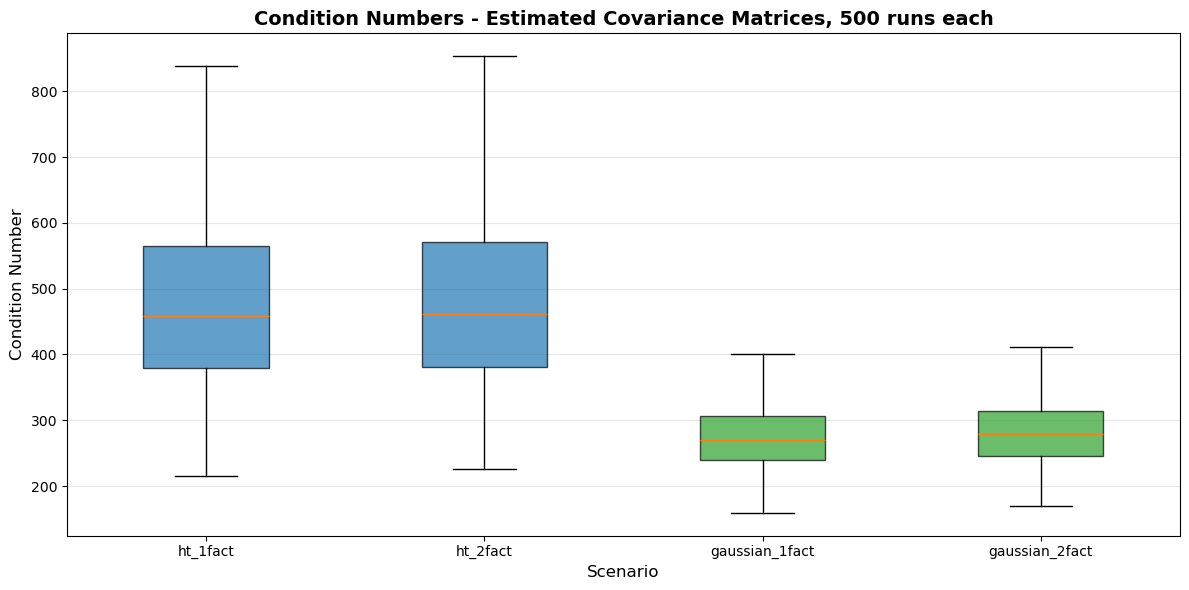

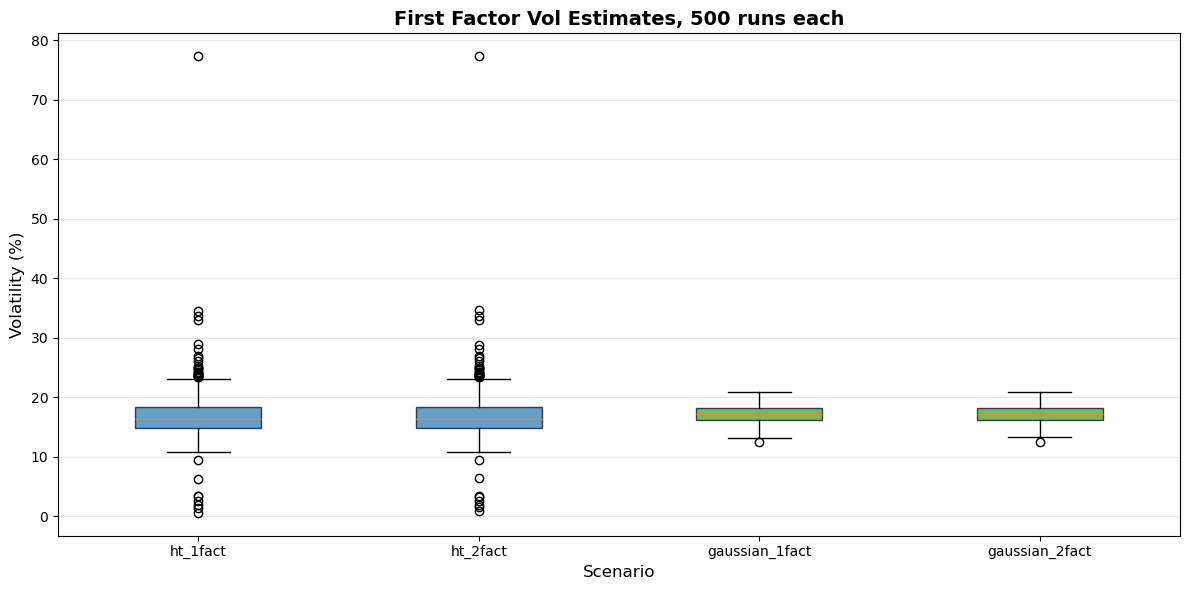

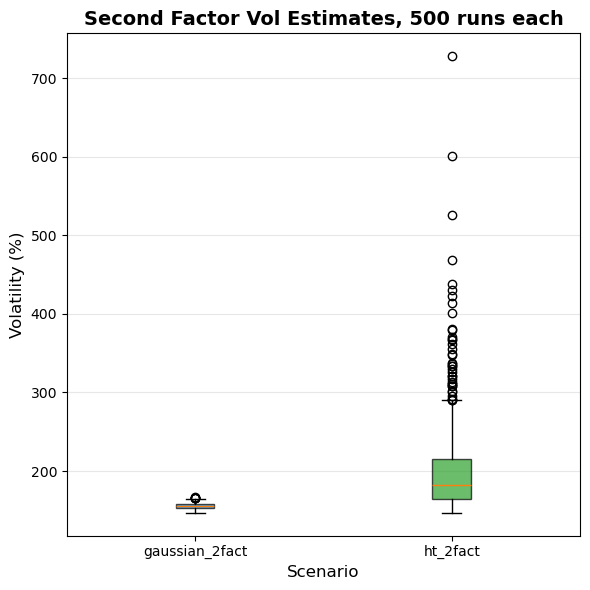

In [41]:
def plot_boxplots(data_dict: Dict[str, list], 
                  title: str,
                  ylabel: str,
                  xlabel: str = "Scenario",
                  figsize: Tuple[int, int] = (12, 6),
                  scenarios = ['ht_1fact', 'ht_2fact', 'gaussian_1fact', 'gaussian_2fact'],
                  colors = ['#1f77b4', '#1f77b4', '#2ca02c', '#2ca02c'],
                  showfliers: bool = True) -> None:
    """
    Generic boxplot plotter for simulation results across 4 scenarios.
    
    Args:
        data_dict: Dict with keys ['ht_1fact', 'ht_2fact', 'gaussian_1fact', 'gaussian_2fact']
        title: Main title for the figure
        ylabel: Y-axis label
        xlabel: X-axis label (default: "Scenario")
        figsize: Figure size (default: (12, 6))
        showfliers: Whether to show outliers (default: True)
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    
    # Prepare data
    data_to_plot = [data_dict[scenario] for scenario in scenarios]
    
    # Create boxplot
    bp = ax.boxplot(data_to_plot, tick_labels=scenarios, patch_artist=True, 
                    showfliers=showfliers, whis=1.5)
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()


# Example: Condition numbers
plot_boxplots(
    condition_numbers,
    title=f'Condition Numbers - Estimated Covariance Matrices, {n_runs} runs each',
    ylabel='Condition Number',
    showfliers=False
)
plot_boxplots(
    s1_estimates,
    title=f'First Factor Vol Estimates, {n_runs} runs each',
    ylabel='Volatility (%)',
    showfliers=True
)
plot_boxplots(
    s2_estimates,
    title=f'Second Factor Vol Estimates, {n_runs} runs each',
    ylabel='Volatility (%)',
    figsize = (6,6),
    scenarios=s2_estimates.keys(),
    colors = ['#1f77b4', '#2ca02c'],
    showfliers=True
)

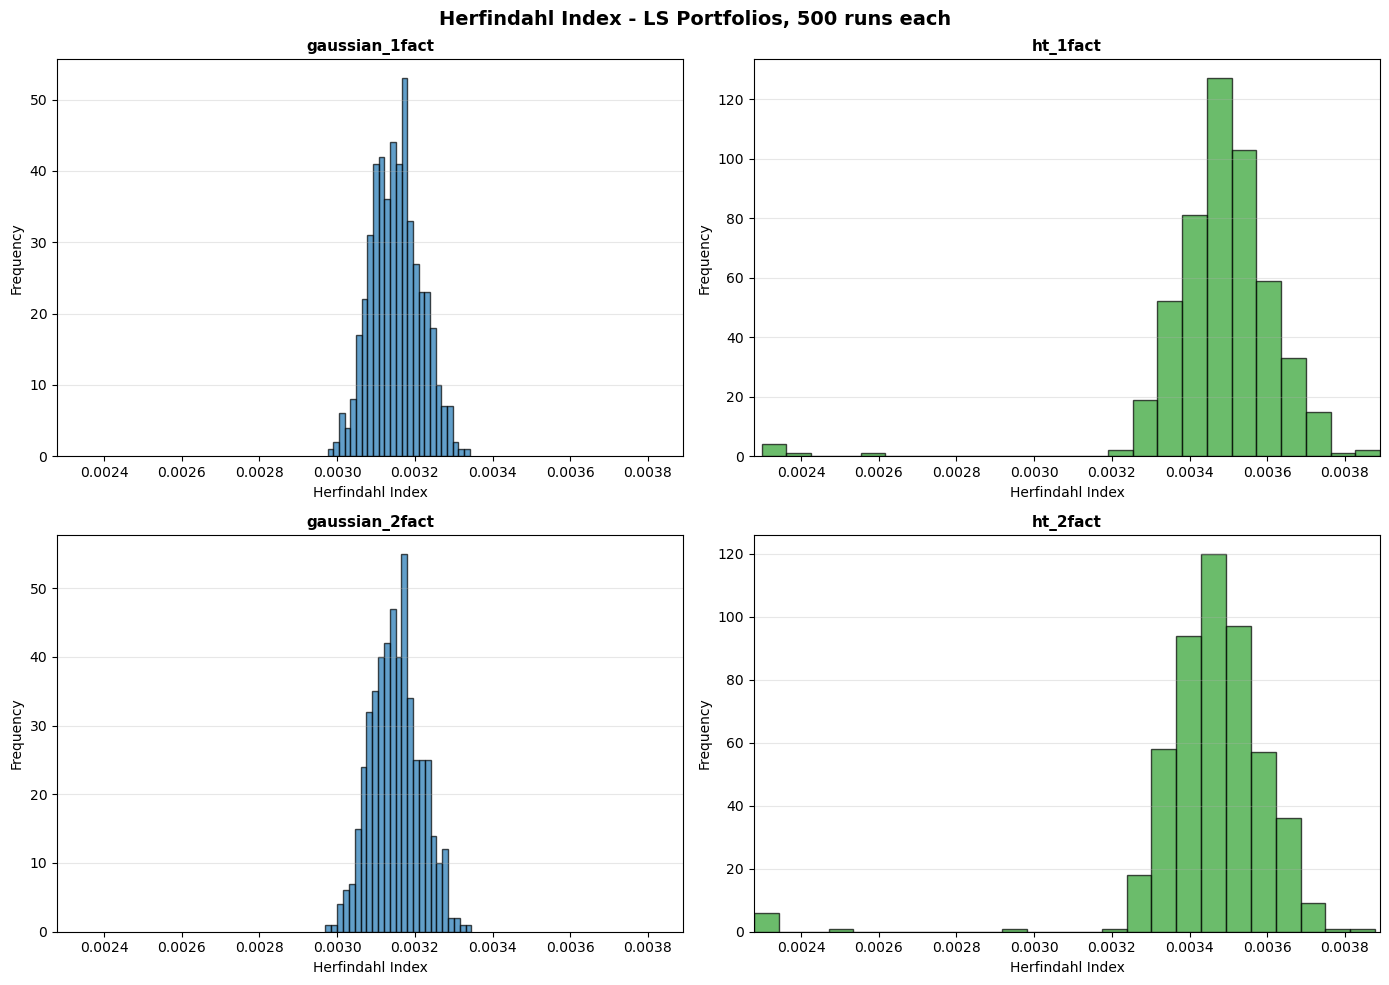

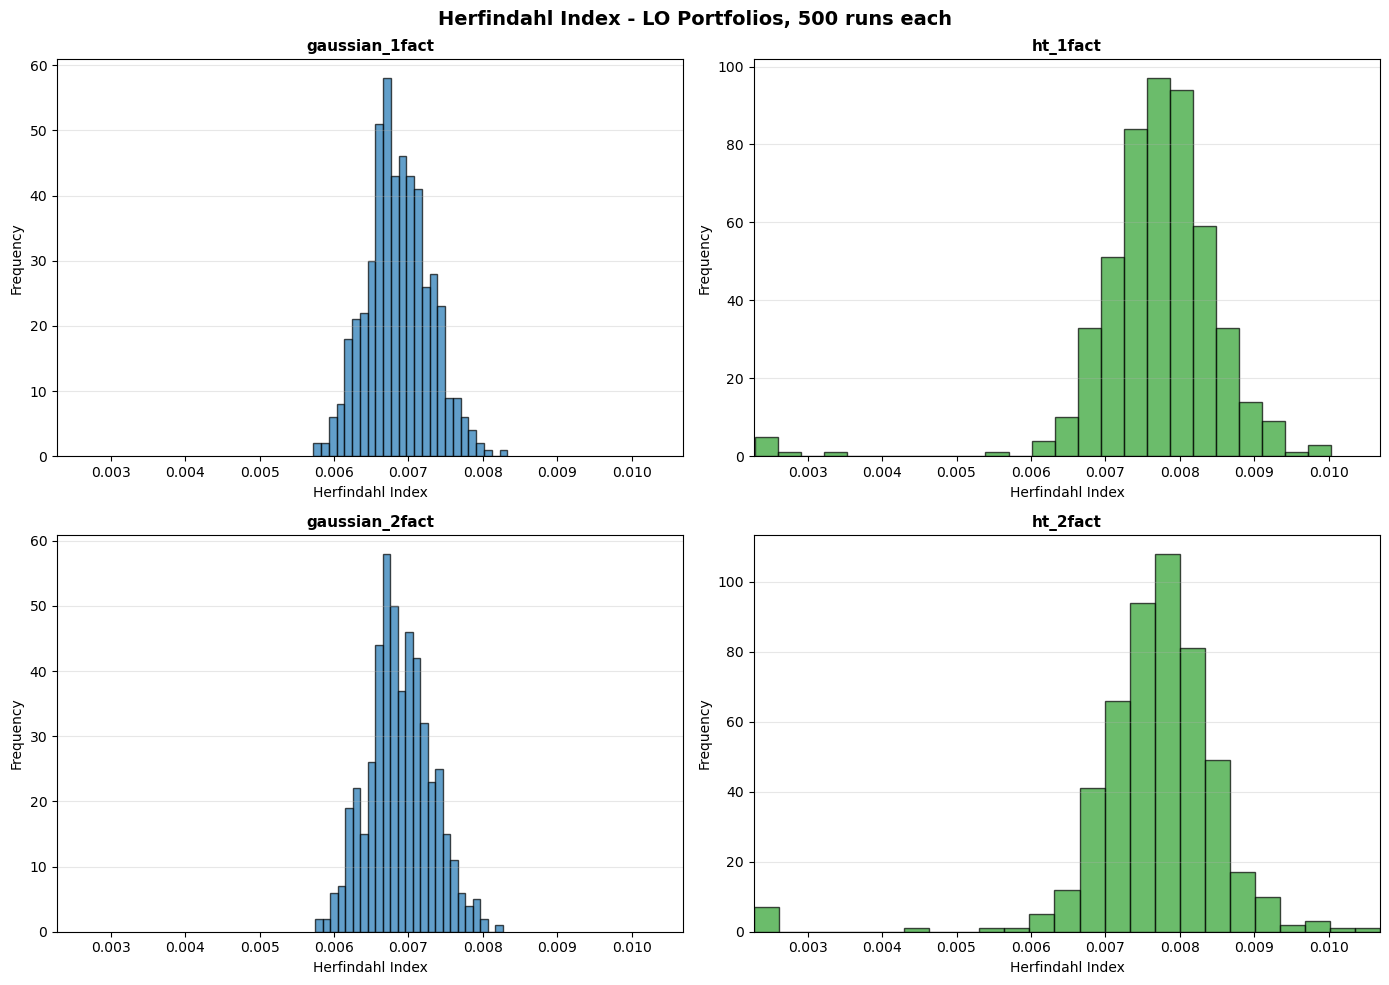

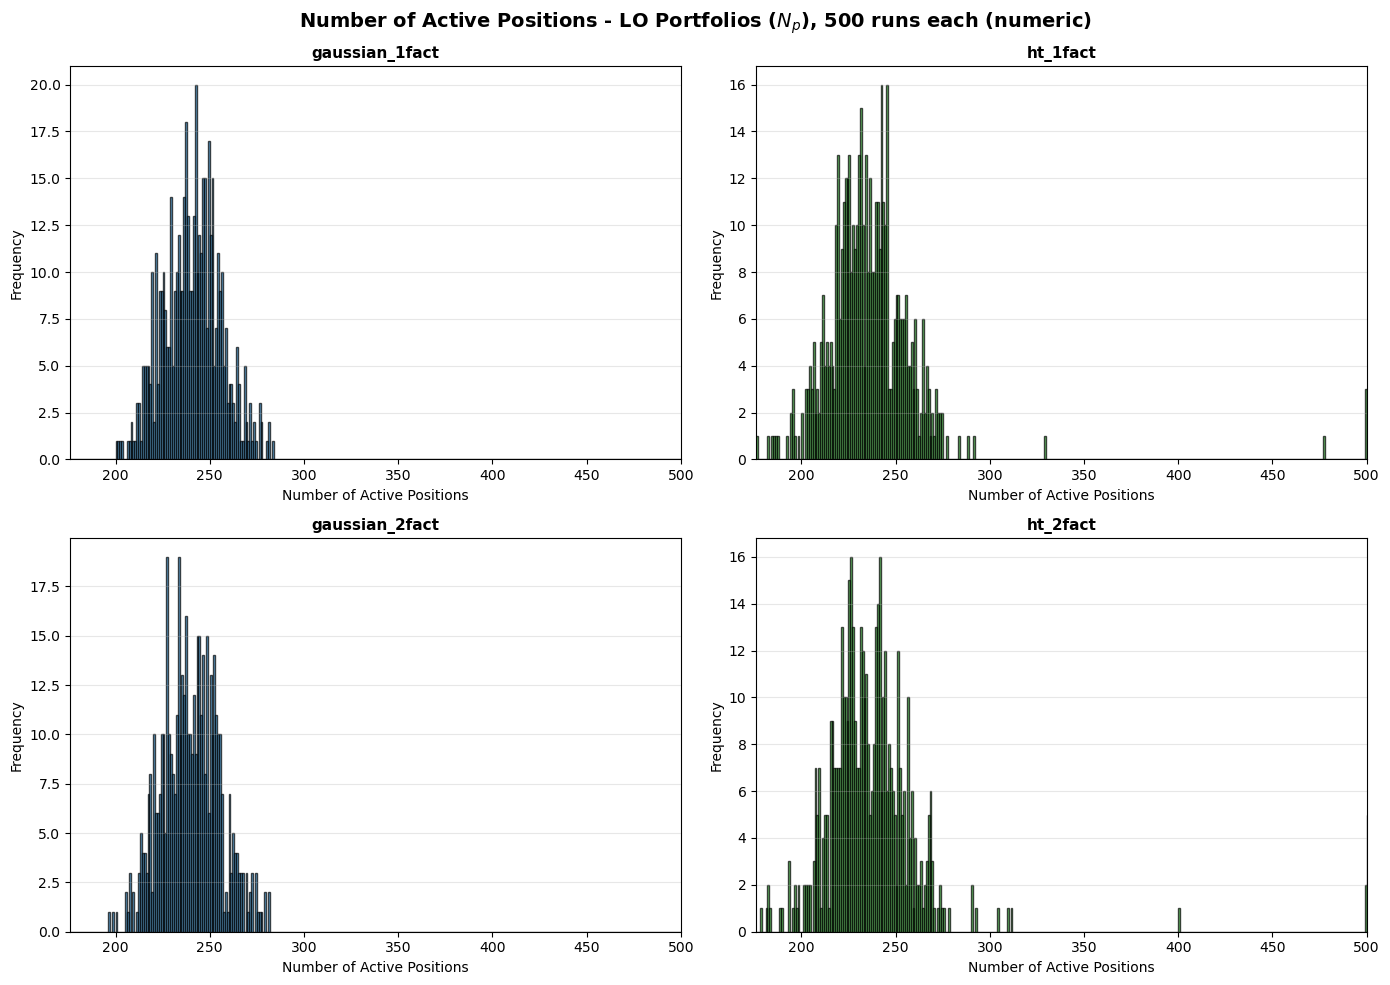

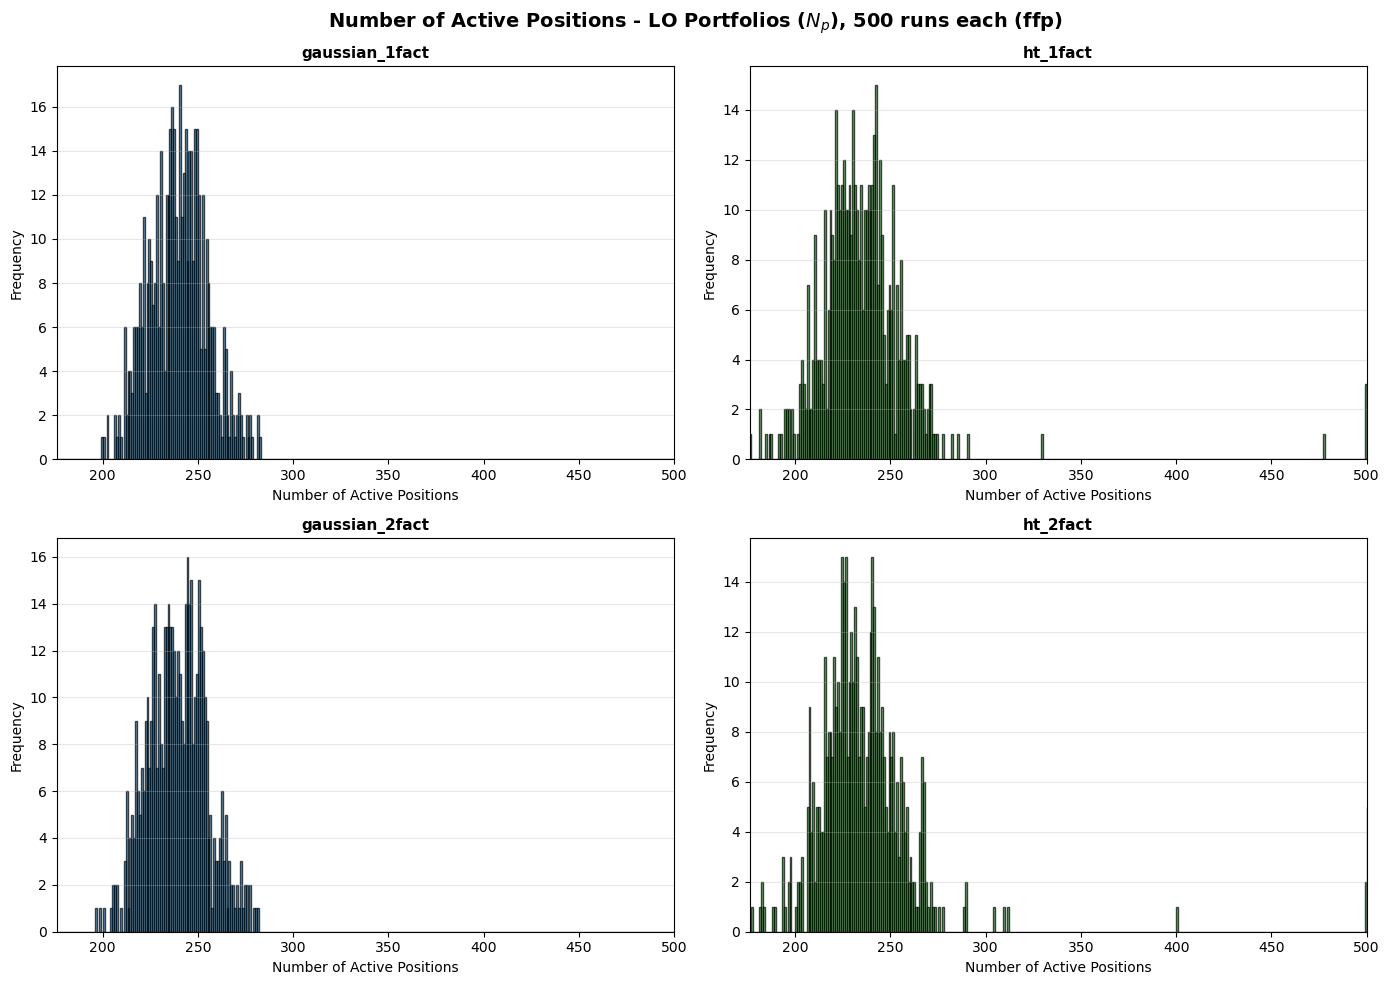

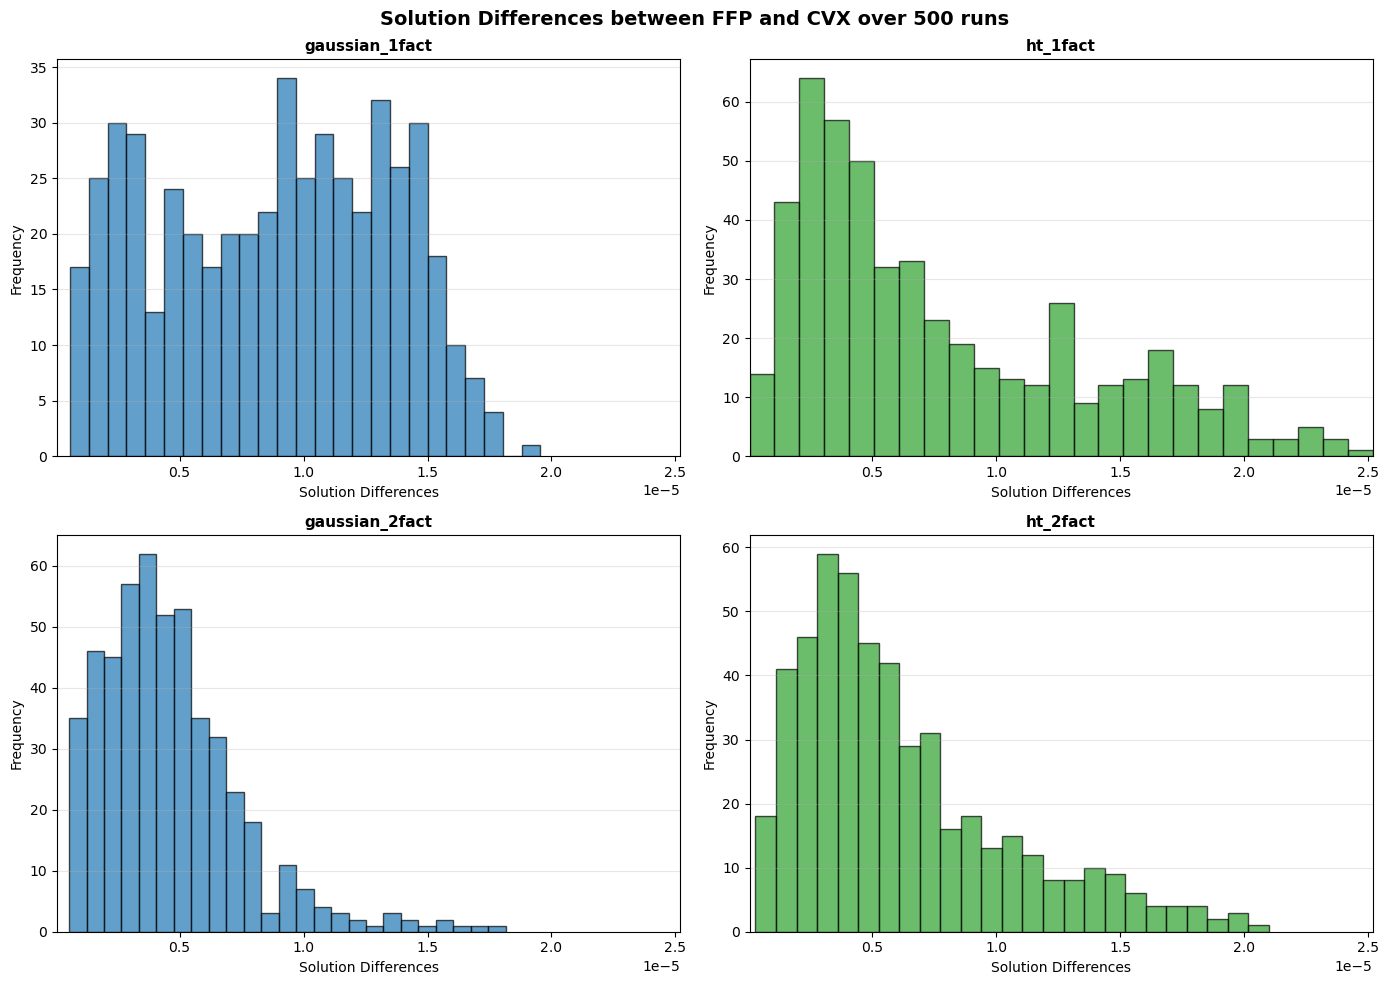

In [42]:
def plot_histograms(data_dict: Dict[str, list], 
                   title: str,
                   xlabel: str,
                   ylabel: str = "Frequency",
                   bins: int = 30,
                   figsize: Tuple[int, int] = (14, 10)) -> None:
    """
    Generic histogram plotter for simulation results across 4 scenarios.
    
    Args:
        data_dict: Dict with keys ['gaussian_1fact', 'gaussian_2fact', 'ht_1fact', 'ht_2fact']
        title: Main title for the figure
        xlabel: X-axis label
        ylabel: Y-axis label (default: "Frequency")
        bins: Number of bins (default: 30, or int array for custom bins)
        figsize: Figure size (default: (14, 10))
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten(order='F')
    
    scenarios = ['gaussian_1fact', 'gaussian_2fact', 'ht_1fact', 'ht_2fact']
    colors = ['#1f77b4', '#1f77b4', '#2ca02c', '#2ca02c']
    
    # Find global min and max for consistent x-axis scaling
    all_data = [val for scenario in scenarios for val in data_dict[scenario]]
    global_min = min(all_data)
    global_max = max(all_data)
    
    # Check if all values are integers
    # all_ints = all(isinstance(x, (int, np.integer)) or (isinstance(x, float) and x == int(x)) for x in all_data)
    all_ints = all(np.all(np.mod(data, 1) == 0) for data in all_data)
    
    # If all ints and bins is a number, use integer bins
    if all_ints and isinstance(bins, int):
        bins = range(int(global_min), int(global_max) + 2)
    
    for idx, scenario in enumerate(scenarios):
        ax = axes[idx]
        data = data_dict[scenario]
        
        ax.hist(data, bins=bins, color=colors[idx], alpha=0.7, edgecolor='black')
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(scenario, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Set consistent x-axis limits across all subplots
        ax.set_xlim(global_min, global_max)
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()




# Herfindahl LS
plot_histograms(
    herfindahl_indices_ls,
    title=f'Herfindahl Index - LS Portfolios, {n_runs} runs each',
    xlabel='Herfindahl Index',
    bins=25
)

# Herfindahl LO
plot_histograms(
    herfindahl_indices_lo,
    title=f'Herfindahl Index - LO Portfolios, {n_runs} runs each',
    xlabel='Herfindahl Index',
    bins=25
)

# Number of active positions
plot_histograms(
    np_counts_lo_numeric,
    title=rf'Number of Active Positions - LO Portfolios ($N_p$), {n_runs} runs each (numeric)',
    xlabel='Number of Active Positions',
    bins=range(0, max([max(v) for v in np_counts_lo_numeric.values()]) + 2)
)

plot_histograms(
    np_counts_lo_ffp,
    title=rf'Number of Active Positions - LO Portfolios ($N_p$), {n_runs} runs each (ffp)',
    xlabel='Number of Active Positions',
    bins=range(0, max([max(v) for v in np_counts_lo_ffp.values()]) + 2)
)

plot_histograms(
    ffp_numeric_solution_differences,
    title=f"Solution Differences between FFP and CVX over {n_runs} runs",
    xlabel='Solution Differences',
    bins=25
)